# Heat Pump 
In this notebook, the electricity demand of heat pumps are modeled. 

Methodology:
- The final heat consumption of countries (TJ) is taken from eurostat nrg_d_hhq
- Total heat demand is considered as sum of space heating + water heating
- Total heat demand is categorized by carrier (natural gas, oil, heat pump and total) in eurostat, so the share of each carrie is calculated as mean of its share over the period of 2010 to 2024.
- max heat pump share will be, when heat pump replace natural gas and oil compeletely
- the total heat demand is modeled using a "regression"/"ML" model to be projected for the future. 
- in each scenario, the year in which max heat pump penetration is reached is defined and the in between values are filled linearly.
- to calculate electricity demand of heat pump, the heat demand is used in this formula:
    
    Demand_HP (TWh) = Total Heat (TJ) * 1/3600 (TWh/TJ) * share_HP * / COP 

- for COP, countries are categorized in 4 groups, using literature! (riviere_european_2009)
- NO LONGER: (As this is only in residential sector, this electricity demand is multiplied by 1.25, in order to account for heat pump demand in service sector.)
- missing values of total heat demand are filled forwardly (ffill()), only 6 values!

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import statsmodels.api as sm
import scipy.stats
from linearmodels import PanelOLS

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

West_EU = ["Germany", "France", "Belgium", "Netherlands", "Luxembourg", "Austria", "Ireland"]
#West_EU = ["Germany", "France", "Belgium", "Netherlands", "Austria"]
East_EU = ["Bulgaria", "Hungary", "Czechia", "Poland", "Romania", "Slovakia"]
South_EU = ["Spain", "Slovenia", "Portugal", "Italy", "Croatia", "Greece"]
Nord_EU = ["Denmark", "Sweden", "Norway", "Finland", "Estonia", "Latvia", "Lithuania"]

ALL_COUNTRIES = West_EU + East_EU + South_EU + Nord_EU

FEATURES = ["population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC"]
FEATURES_ln = ["ln_pop", "ln_gdp_pc", "ln_hdd"]

In [126]:
nrg_d_hhq = pd.read_csv("Heat Pump/eurostat_nrg_d_hhq.csv")

# selecting only the wanted columns and renaming name
nrg_d_hhq = nrg_d_hhq[["nrg_bal", "Standard international energy product classification (SIEC)", "Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]
nrg_d_hhq= nrg_d_hhq.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "Energy_TJ",
    "Standard international energy product classification (SIEC)": "carrier"
})  

# sum of both space heating and water heating
nrg_d_hhq_heating = (
    nrg_d_hhq
    .groupby(["carrier", "country", "year"], as_index=False)["Energy_TJ"]
    .sum()
)

# Get the "Total" value for each country-year
totals = (
    nrg_d_hhq_heating[nrg_d_hhq_heating["carrier"] == "Total"]
    [["country", "year", "Energy_TJ"]]
    .rename(columns={"Energy_TJ": "Total_Energy_TJ"})
)

# Merge totals back to the main dataframe
nrg_d_hhq_heating = nrg_d_hhq_heating.merge(
    totals,
    on=["country", "year"],
    how="left"
)

# Compute share
nrg_d_hhq_heating["share_pu"] = (
    nrg_d_hhq_heating["Energy_TJ"] /
    nrg_d_hhq_heating["Total_Energy_TJ"]
)

#nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Total") & (nrg_d_hhq_heating.country=="Norway")]
nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.country=="Norway")]

,carrier,country,year,Energy_TJ,Total_Energy_TJ,share_pu
266,Ambient heat (heat pumps),Norway,2010,11512.733,162095.646,0.071024
267,Ambient heat (heat pumps),Norway,2011,13142.041,142568.038,0.092181
268,Ambient heat (heat pumps),Norway,2012,14325.567,152644.809,0.093849
269,Ambient heat (heat pumps),Norway,2013,15333.532,148644.257,0.103156
270,Ambient heat (heat pumps),Norway,2014,16145.614,137059.737,0.117800
...,...,...,...,...,...,...
2190,Total,Norway,2019,149993.423,149993.423,1.000000
2191,Total,Norway,2020,151153.384,151153.384,1.000000
2192,Total,Norway,2021,160221.922,160221.922,1.000000
2193,Total,Norway,2022,148515.999,148515.999,1.000000


In [127]:
# saving the historical data of heat pump heat consumption to be used for historical electricity demand of them.
hist_hp_demand = nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Ambient heat (heat pumps)")]
hist_hp_demand.to_csv("Data - raw/prepared_data/hist_hp_heat_demand.csv")

In [128]:
# calculating average share of each carrier over 2010 to 2024
carrier_shares = nrg_d_hhq_heating.groupby(["country", "carrier"], as_index=False)["share_pu"].mean()
carrier_shares = carrier_shares[(carrier_shares.carrier!="Total")
                                & (carrier_shares.carrier!="Gas oil and diesel oil")
                                & (carrier_shares.carrier!="Liquefied petroleum gases")
                                ]
carrier_shares[carrier_shares.country=="Norway"]#.sum()

,country,carrier,share_pu
108,Norway,Ambient heat (heat pumps),0.123564
111,Norway,Natural gas,0.000788
112,Norway,Oil and petroleum products,0.021572


In [129]:
# caculating the maximum available share of Heat pumps per country
max_hp_share = carrier_shares.groupby(["country"])["share_pu"].sum()
max_hp_share

country
Austria        0.440016
Belgium        0.829804
Bulgaria       0.040029
Croatia        0.297118
Czechia        0.299351
Denmark        0.253124
Estonia        0.062948
Finland        0.160295
France         0.554859
Germany        0.713357
Greece         0.553204
Hungary        0.533975
Ireland        0.767110
Italy          0.683067
Latvia         0.104440
Lithuania      0.176030
Luxembourg     0.896873
Netherlands    0.879446
Norway         0.145923
Poland         0.212406
Portugal       0.495350
Romania        0.364833
Slovakia       0.548471
Slovenia       0.306233
Spain          0.637404
Sweden         0.032608
Name: share_pu, dtype: float64

In [130]:
# Handling the Assumptions of Norway and Finnland:
# The mean value of max available hp_share is less then the hp share in 2024. Therefore I will use the maximum value
# the hp_share had during the period of 2010 to 2024, plus the oil and gas share in the corresponding year
No_Fin_carrier_share = nrg_d_hhq_heating[
    (nrg_d_hhq_heating.country.isin(["Norway", "Finland"]))
    & (nrg_d_hhq_heating.carrier.isin(["Ambient heat (heat pumps)", "Natural gas", "Oil and petroleum products"]))
]

No_Fin_carrier_share = No_Fin_carrier_share[["carrier", "country", "year", "share_pu"]]

No_Fin_carrier_share = No_Fin_carrier_share.pivot(index={"year", "country"}, columns="carrier", values="share_pu")


max_hp_share.Norway = No_Fin_carrier_share.loc["Norway", 2023].sum()
#max_hp_share.Norway = No_Fin_carrier_share.loc[2023, "Norway"].sum()
max_hp_share.Finland = No_Fin_carrier_share.loc["Finland", 2023].sum()
#max_hp_share.Finland = No_Fin_carrier_share.loc[2023, "Finland"].sum()

max_hp_share

country
Austria        0.440016
Belgium        0.829804
Bulgaria       0.040029
Croatia        0.297118
Czechia        0.299351
Denmark        0.253124
Estonia        0.062948
Finland        0.181114
France         0.554859
Germany        0.713357
Greece         0.553204
Hungary        0.533975
Ireland        0.767110
Italy          0.683067
Latvia         0.104440
Lithuania      0.176030
Luxembourg     0.896873
Netherlands    0.879446
Norway         0.170314
Poland         0.212406
Portugal       0.495350
Romania        0.364833
Slovakia       0.548471
Slovenia       0.306233
Spain          0.637404
Sweden         0.032608
Name: share_pu, dtype: float64

In [131]:
# seperating the target values of the model in heat_demand
heat_demand = nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Total")]
heat_demand = heat_demand[["country", "year", "Total_Energy_TJ"]]
heat_demand = heat_demand.rename(columns=
                                 {"Total_Energy_TJ": "Total_Heat_TJ"}
                                 )

# Norway value for 2024 is missing in csv file! so it is filled manually:
# Total, space heating: 131173.441 & water heating: 25183.669
new_row = pd.DataFrame({
    "country": ["Norway"],
    "year": [2024],
    "Total_Heat_TJ": [131173.441 + 25183.669]
})
heat_demand = pd.concat([heat_demand, new_row], ignore_index=True)


#heat_demand[(heat_demand.country=="Norway") & (heat_demand.year==2024)]

heat_demand

,country,year,Total_Heat_TJ
0,Austria,2010,251955.007
1,Austria,2011,232075.458
2,Austria,2012,237258.529
3,Austria,2013,247036.708
4,Austria,2014,221009.108
...,...,...,...
379,Sweden,2021,223346.499
380,Sweden,2022,208850.634
381,Sweden,2023,214675.124
382,Sweden,2024,210038.766


In [132]:
# importing panel data for population, gdp per capita and HDD
panel = pd.read_csv("Data - raw/prepared_data/panel_transformed.csv")
panel = panel[["year", "country"] + FEATURES_ln]

In [133]:
# creating the training set of histroical data
hist = panel[panel.year <= 2024]
hist = hist.merge(heat_demand, on=["year", "country"], how="left")
hist = hist[hist.year >= 2010]

# missing values: filling forwardly
hist = hist.sort_values(["country", "year"])
hist["Total_Heat_TJ"] = (
    hist.groupby("country")["Total_Heat_TJ"]
    .ffill()
)

hist = hist.set_index(["country", "year"])

hist#[hist.country=="Lithuania"]

ln_pop  ln_gdp_pc    ln_hdd  Total_Heat_TJ
country year                                              
Austria 2010  2.235552  10.995348  8.272347     251955.007
        2011  2.238064  11.022102  8.074398     232075.458
        2012  2.241573  11.024084  8.146563     237258.529
        2013  2.246212  11.015196  8.152612     247036.708
        2014  2.252111  11.016199  8.149901     221009.108
...                ...        ...       ...            ...
Sweden  2020  2.427241  10.994286  8.442473     209761.269
        2021  2.431795  11.044091  8.447937     223346.499
        2022  2.438193  11.048954  8.297176     208850.634
        2023  2.444220  11.043282  8.248988     214675.124
        2024  2.446833  11.044723  8.373914     210038.766

[390 rows x 4 columns]

In [134]:
# Replacing values of Zero with NaN and then fill them backward for each country!
# replace 0 with NaN
hist["Total_Heat_TJ"] = (
    hist["Total_Heat_TJ"]
    .replace(0, np.nan)
)

# fill using next available year within each country
hist["Total_Heat_TJ"] = (
    hist.groupby(level="country")["Total_Heat_TJ"]
    .bfill()
)

In [135]:
# preparing the projection input data
proj = panel[panel.year > 2024]

proj = proj.set_index(["country", "year"])

proj

,,ln_pop,ln_gdp_pc,ln_hdd
country,year,,,
Austria,2025,2.322114,11.050321,8.125675
Belgium,2025,2.555947,11.060191,7.648291
Bulgaria,2025,2.006516,10.467513,7.767877
Croatia,2025,1.583987,10.703079,7.495500
Czechia,2025,2.477336,10.797186,7.954813
...,...,...,...,...
Romania,2060,2.852642,11.187993,7.841816
Slovakia,2060,1.766487,11.146595,7.957286
Slovenia,2060,1.114359,11.312611,7.715048


# Plotting function

In [136]:
def plot_heat_demand(
    hist,
    proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # or "ML_predictions"
    proj_pred_col="Total_Heat_TJ",          # or "Total_Heat_TJ_PanelOLS" / "Total_Heat_TJ_ML"
    countries_list=None,
    title="Heat Demand: Actuals, Model Fit & Projection",
    test_split_year=2020,
):
    """
    Grid plot of heat demand for every country (max 3 columns).

    Parameters
    ----------
    hist            : DataFrame with (country, year) MultiIndex
    proj            : DataFrame with (country, year) MultiIndex
    hist_actual_col : column in hist plotted as solid blue (actuals)
    hist_pred_col   : column in hist plotted as dotted orange (model predictions)
    proj_pred_col   : column in proj plotted as dashed green (projection)
    countries_list  : countries to include (default: all in hist index)
    year            : draw a vertical red dotted line at this year (default: 2020)
    """
    if countries_list is None:
        countries_list = sorted(hist.index.get_level_values("country").unique().tolist())

    n     = len(countries_list)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(15, nrows * 3),
        constrained_layout=True,
    )
    axes_flat = axes.flatten()

    for i, country in enumerate(countries_list):
        ax = axes_flat[i]

        # ── Actual historical values (solid blue) ───────────────────────────
        try:
            actual = hist[hist_actual_col].xs(country, level="country")
            ax.plot(actual.index, actual.values,
                    "-", color="steelblue", lw=1.5, label="Actual")
        except KeyError:
            pass

        # ── Historical model predictions (dotted orange) ────────────────────
        if hist_pred_col in hist.columns:
            try:
                pred = hist[hist_pred_col].xs(country, level="country")
                ax.plot(pred.index, pred.values,
                        ":", color="darkorange", lw=1.8, label=f"Model ({hist_pred_col})")
            except KeyError:
                pass

        # ── Future projection (dashed green) ────────────────────────────────
        if proj_pred_col in proj.columns:
            try:
                fut = proj[proj_pred_col].xs(country, level="country")
                ax.plot(fut.index, fut.values,
                        "--", color="seagreen", lw=1.5, label=f"Projection ({proj_pred_col})")
            except KeyError:
                pass

        # ── Train/test split line (red dotted vertical) ──────────────────────
        #ax.axvline(x=test_split_year, color="red", linestyle=":", lw=1.5, label=f"Test split ({test_split_year})", alpha=0.3)
        if test_split_year is not None:
            ax.axvline(x=test_split_year, color="red", lw=1.0, ls="--", alpha=0.3,
                        label=f"Train/Test split ({test_split_year})" if i == 0 else "_nolegend_")

        ax.set_title(country, fontsize=9, fontweight="bold")
        ax.set_ylabel("Heat Consumption (TJ)", fontsize=7)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_ylim(bottom=0)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared legend above the grid
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.04)

    #plt.savefig("heat_demand_forecast.png", dpi=120, bbox_inches="tight")
    #plt.show()
    return None#fig

# ── Call with PanelOLS predictions ───────────────────────────────────────────
"""plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="Total_Heat_TJ",          # change to "Total_Heat_TJ_ML" when ready
)"""

# ── Example: swap in ML predictions once available ───────────────────────────
# plot_heat_demand(hist, proj, hist_pred_col="ML_predictions", proj_pred_col="Total_Heat_TJ_ML")


# ── Diagnosis: train vs. test metrics for the ORIGINAL model ─────────────────
def report_metrics(label, y_true, y_pred):
    mask = y_true != 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask])
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"{label:10s}  MAPE={mape*100:6.2f}%  MAE={mae:,.0f}  RMSE={rmse:,.0f}  R²={r2:.4f}")

# Clustreing

In [137]:
"""CLUSTER = West_EU # or West_EU / East_EU / South_EU / Nord_EU / ["Germany"] / etc.
#CLUSTER = ["Germany"]
hist = hist[hist.index.get_level_values('country').isin(CLUSTER)]
proj = proj[proj.index.get_level_values('country').isin(CLUSTER)]"""

'CLUSTER = West_EU # or West_EU / East_EU / South_EU / Nord_EU / ["Germany"] / etc.\n#CLUSTER = ["Germany"]\nhist = hist[hist.index.get_level_values(\'country\').isin(CLUSTER)]\nproj = proj[proj.index.get_level_values(\'country\').isin(CLUSTER)]'

# PanelOLS Model

In [138]:
"""# add interaction & combined features to both dataframes
for df in [hist, proj]:
    df["gdp_total"]     = df["population_Mio"] * df["gdp_per_capita_USD"] / 1000  # total GDP [B USD]
    df["hdd_x_pop"]     = df["hdd_DegreesC"]   * df["population_Mio"]             # heating load × population


FEATURES_ENG = FEATURES + ["gdp_total", "hdd_x_pop"]"""

'# add interaction & combined features to both dataframes\nfor df in [hist, proj]:\n    df["gdp_total"]     = df["population_Mio"] * df["gdp_per_capita_USD"] / 1000  # total GDP [B USD]\n    df["hdd_x_pop"]     = df["hdd_DegreesC"]   * df["population_Mio"]             # heating load × population\n\n\nFEATURES_ENG = FEATURES + ["gdp_total", "hdd_x_pop"]'

In [139]:
hist["ln_total_heat"] = np.log1p(hist['Total_Heat_TJ'])
#hist

In [140]:
X = sm.add_constant(hist[FEATURES_ln])
#Y = hist[["Total_Heat_TJ"]]
Y = hist[["ln_total_heat"]]

m_panelOLS = PanelOLS(Y, X,
                    entity_effects=True, 
                    #time_effects=True
                    ).fit(
                        cov_type="clustered", 
                        cluster_entity=True,
                        #cluster_time=True
                        )
m_panelOLS

Dep. Variable:,ln_total_heat,R-squared:,0.0665
Estimator:,PanelOLS,R-squared (Between):,-0.8802
No. Observations:,390,R-squared (Within):,0.0665
Date:,"Wed, Jun 10 2026",R-squared (Overall):,-0.8755
Time:,10:34:58,Log-likelihood,437.50
Cov. Estimator:,Clustered,,
,,F-statistic:,8.5776
Entities:,26,P-value,0.0000
Avg Obs:,15.000,Distribution:,"F(3,361)"
Min Obs:,15.000,,
Max Obs:,15.000,F-statistic (robust):,5.6069


In [141]:
# calculating model for historical data
hist["panel_predictions"] = np.expm1(m_panelOLS.predict(X))
#hist["panel_predictions"] = m_panelOLS.predict(X)

# forecasting future values
X_proj = sm.add_constant(proj)

proj["Total_Heat_TJ_panel"] = np.expm1(m_panelOLS.predict(X_proj))
#proj["Total_Heat_TJ_panel"] = m_panelOLS.predict(X_proj)
#proj

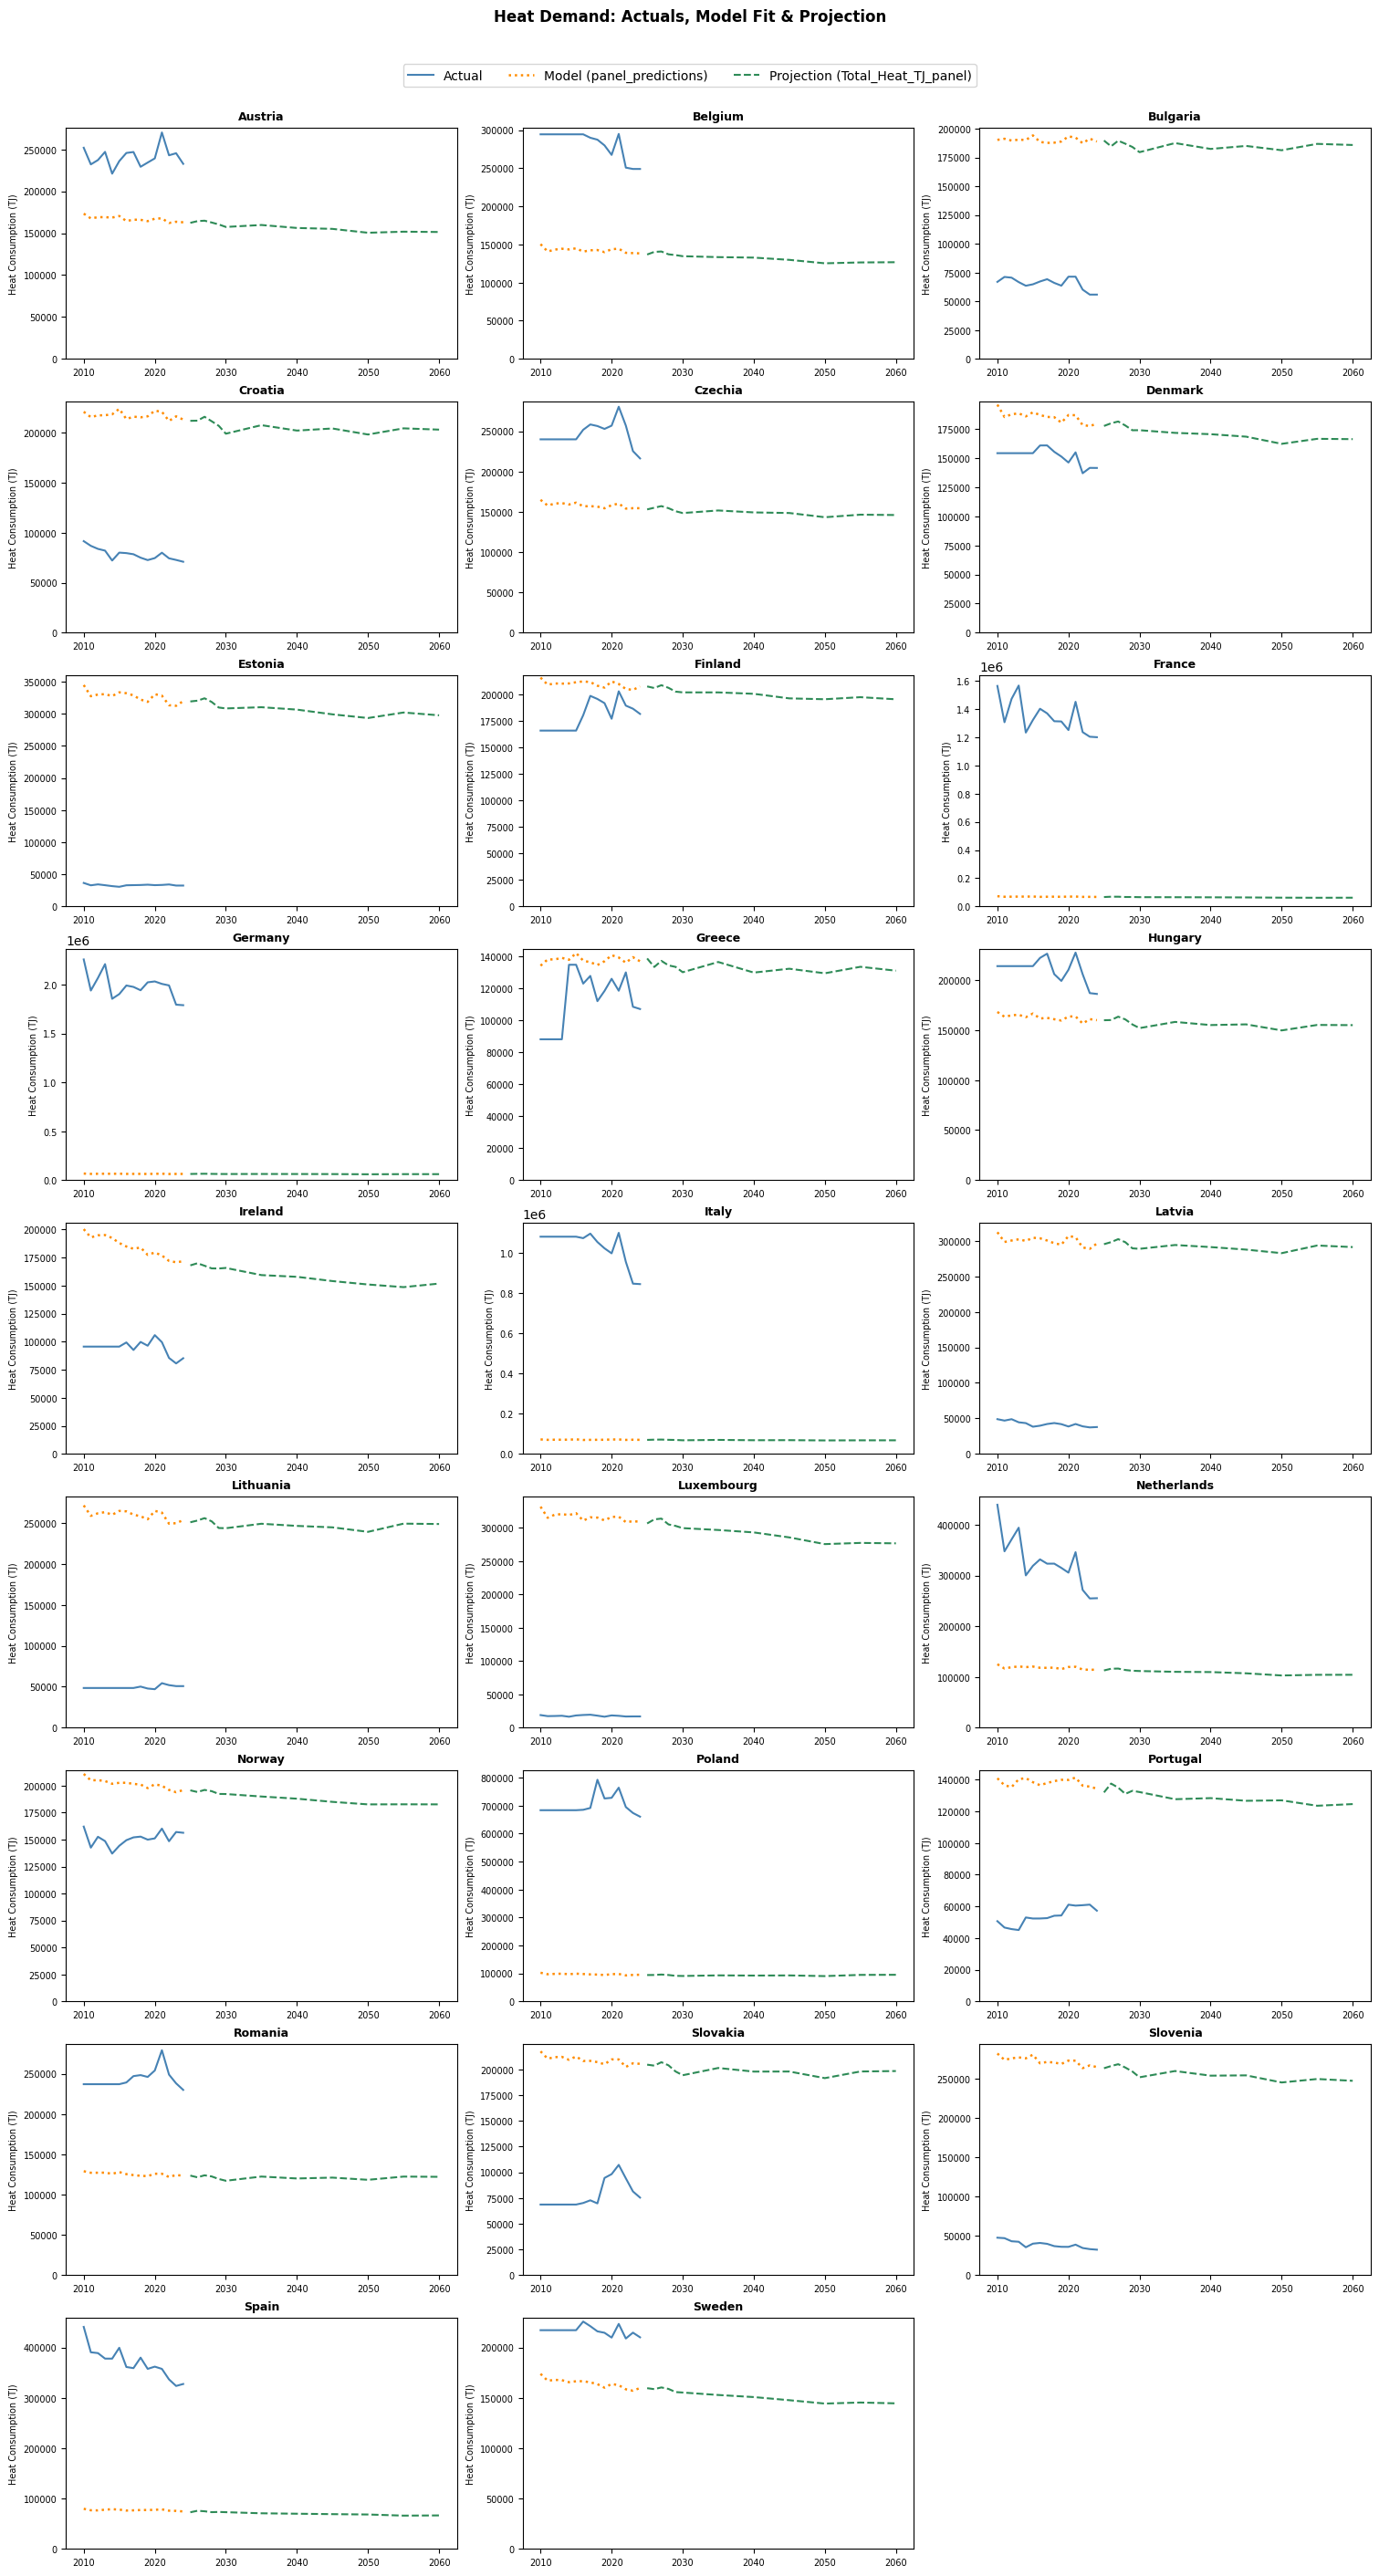

In [142]:
# plotting the results of PanelOLS model
plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="Total_Heat_TJ_panel",          # change to "Total_Heat_TJ_ML" when ready
    test_split_year=None
)

## Calibration – PanelOLS projection anchored to 2024 actuals
The pooled PanelOLS explains **cross-country differences** well (Between-R² ≈ 0.92) 
but the absolute level per country can deviate from the actual 2024 value.  
Calibration computes a per-country factor `actual_2024 / modeled_2024` and scales every 
projected year by it — each country starts exactly from its known 2024 value while the model drives the trajectory.

Calibration factors (actual / modeled @ 2024):
country
Slovenia        0.122367
Latvia          0.127514
Croatia         0.332617
Slovakia        0.366973
Portugal        0.426416
Ireland         0.496440
Greece          0.782002
Denmark         0.788644
Norway          0.797996
Finland         0.874946
Hungary         1.164033
Sweden          1.314999
Czechia         1.400336
Austria         1.428075
Romania         1.864526
Netherlands     2.232598
Spain           4.406790
Poland          6.932684
Italy          12.095560
France         17.923465
Germany        28.203674
Belgium              NaN
Bulgaria             NaN
Estonia              NaN
Lithuania            NaN
Luxembourg           NaN


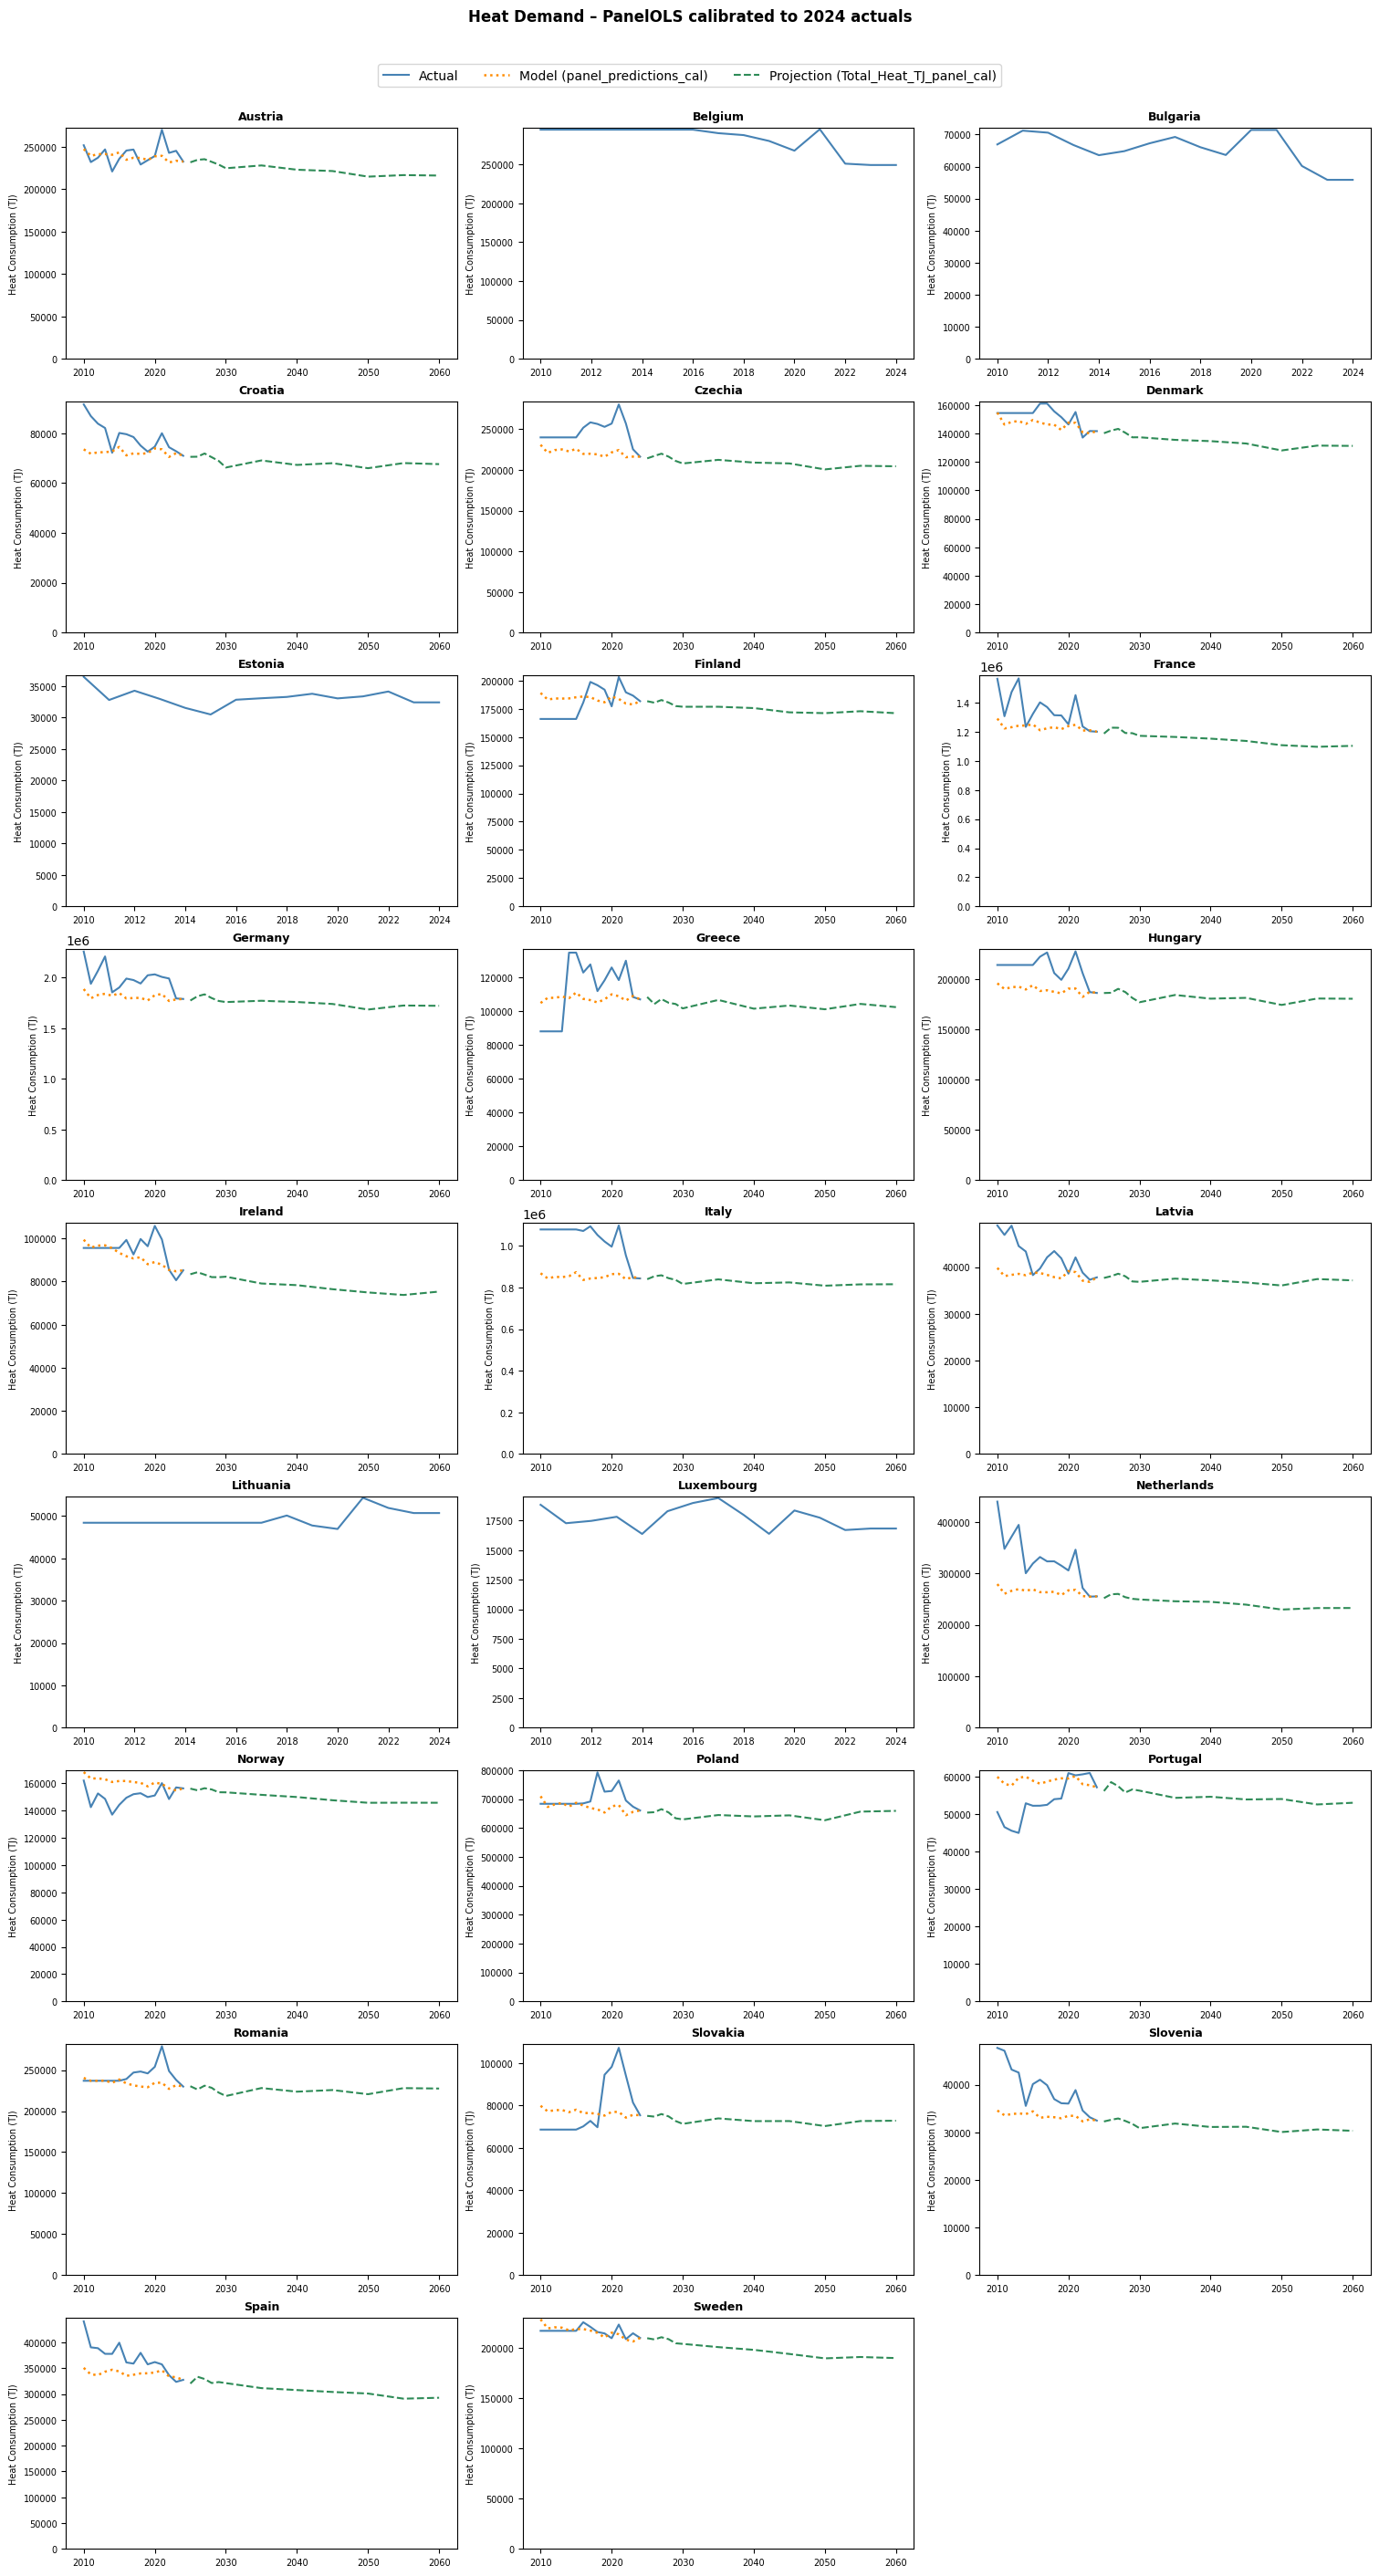

In [143]:
# Calibration factor per country: actual 2024 / modeled 2024
actual_2024  = (heat_demand[heat_demand["year"] == 2024]
                .set_index("country")["Total_Heat_TJ"])

modeled_2024 = (hist.xs(2024, level="year")["panel_predictions"])

cal_factor_panel = actual_2024 / modeled_2024

# Apply to historical modelled: scale each country's values by its factor
hist["panel_predictions_cal"] = (
    hist["panel_predictions"]
    * hist.index.get_level_values("country").map(cal_factor_panel)
)

# Apply to projection: scale each country's future values by its factor
proj["Total_Heat_TJ_panel_cal"] = (
    proj["Total_Heat_TJ_panel"]
    * proj.index.get_level_values("country").map(cal_factor_panel)
)

# Compare calibrated vs. uncalibrated for a spot-check
plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions_cal",
    proj_pred_col="Total_Heat_TJ_panel_cal",
    title="Heat Demand – PanelOLS calibrated to 2024 actuals",
    test_split_year=None,
)

print("Calibration factors (actual / modeled @ 2024):")
print(cal_factor_panel.sort_values().to_string())

## First Differences Model -- captures within-country time dynamics

Instead of modelling **levels** (which collapses the Within-R² with entity FE), 
we model **year-on-year changes**:

$$\Delta \text{Heat}_{it} = \beta_1 \cdot \Delta\text{Pop}_{it} + \beta_2 \cdot \Delta\text{GDP\_pc}_{it} + \beta_3 \cdot \Delta\text{HDD}_{it} + \varepsilon_{it}$$

Entity fixed effects are eliminated automatically by differencing — no FE needed.  
**Projection:** predicted $\Delta$Heat values are accumulated from the known 2024 actual baseline.

In [144]:
"""from linearmodels import PooledOLS

# Columns to first-difference (GDP growth rate excluded – already a rate)
_FD_COLS    = ["Total_Heat_TJ", "population_Mio", "gdp_per_capita_USD", "hdd_DegreesC"]
FEATURES_FD = ["d_population_Mio", "d_gdp_per_capita_USD", "d_hdd_DegreesC"]

_hist_tmp = hist[_FD_COLS].reset_index().sort_values(["country", "year"])
for col in _FD_COLS:
    _hist_tmp[f"d_{col}"] = _hist_tmp.groupby("country")[col].diff()

hist_fd = (_hist_tmp
           .dropna(subset=["d_Total_Heat_TJ"] + FEATURES_FD)
           .set_index(["country", "year"]))

Y_fd = hist_fd[["d_Total_Heat_TJ"]]
X_fd = sm.add_constant(hist_fd[FEATURES_FD])

m_fd = PooledOLS(Y_fd, X_fd).fit(cov_type="clustered", cluster_entity=True)
print(m_fd)

# In-sample fit on differences
hist_fd["d_Heat_pred"] = (X_fd * m_fd.params).sum(axis=1)
print(f"\nR\u00b2 on annual \u0394Heat (in-sample): "
      f"{r2_score(hist_fd['d_Total_Heat_TJ'], hist_fd['d_Heat_pred']):.4f}")"""

'from linearmodels import PooledOLS\n\n# Columns to first-difference (GDP growth rate excluded – already a rate)\n_FD_COLS    = ["Total_Heat_TJ", "population_Mio", "gdp_per_capita_USD", "hdd_DegreesC"]\nFEATURES_FD = ["d_population_Mio", "d_gdp_per_capita_USD", "d_hdd_DegreesC"]\n\n_hist_tmp = hist[_FD_COLS].reset_index().sort_values(["country", "year"])\nfor col in _FD_COLS:\n    _hist_tmp[f"d_{col}"] = _hist_tmp.groupby("country")[col].diff()\n\nhist_fd = (_hist_tmp\n           .dropna(subset=["d_Total_Heat_TJ"] + FEATURES_FD)\n           .set_index(["country", "year"]))\n\nY_fd = hist_fd[["d_Total_Heat_TJ"]]\nX_fd = sm.add_constant(hist_fd[FEATURES_FD])\n\nm_fd = PooledOLS(Y_fd, X_fd).fit(cov_type="clustered", cluster_entity=True)\nprint(m_fd)\n\n# In-sample fit on differences\nhist_fd["d_Heat_pred"] = (X_fd * m_fd.params).sum(axis=1)\nprint(f"\nR² on annual ΔHeat (in-sample): "\n      f"{r2_score(hist_fd[\'d_Total_Heat_TJ\'], hist_fd[\'d_Heat_pred\']):.4f}")'

In [145]:
"""# Build bridge: hist 2024 features + all projection years → compute ΔFeatures
_hist_2024 = (hist.xs(2024, level="year")[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC"]]
              .reset_index().assign(year=2024))

_combined = (pd.concat([_hist_2024,
                         proj[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC"]].reset_index()])
             .sort_values(["country", "year"]))

for col in ["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC"]:
    _combined[f"d_{col}"] = _combined.groupby("country")[col].diff()

_proj_fd = _combined[_combined["year"] > 2024].copy()
X_proj_fd = sm.add_constant(_proj_fd[FEATURES_FD])
_proj_fd["d_Heat_pred"] = (X_proj_fd * m_fd.params).sum(axis=1).values

# Accumulate predicted ΔHeat from each country's 2024 actual baseline
_rows = []
for country, grp in _proj_fd.groupby("country"):
    _base = heat_demand.loc[
        (heat_demand["country"] == country) & (heat_demand["year"] == 2024),
        "Total_Heat_TJ"
    ].values
    if len(_base) == 0:
        continue
    grp = grp.sort_values("year").copy()
    grp["Total_Heat_TJ_FD"] = _base[0] + grp["d_Heat_pred"].cumsum()
    _rows.append(grp)

proj["Total_Heat_TJ_FD"] = (pd.concat(_rows)
                              .set_index(["country", "year"])["Total_Heat_TJ_FD"])

plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col=None,
    proj_pred_col="Total_Heat_TJ_FD",
    title="Heat Demand \u2013 First Differences (accumulated from 2024 actuals)",
    test_split_year=None,
)"""

'# Build bridge: hist 2024 features + all projection years → compute ΔFeatures\n_hist_2024 = (hist.xs(2024, level="year")[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC"]]\n              .reset_index().assign(year=2024))\n\n_combined = (pd.concat([_hist_2024,\n                         proj[["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC"]].reset_index()])\n             .sort_values(["country", "year"]))\n\nfor col in ["population_Mio", "gdp_per_capita_USD", "hdd_DegreesC"]:\n    _combined[f"d_{col}"] = _combined.groupby("country")[col].diff()\n\n_proj_fd = _combined[_combined["year"] > 2024].copy()\nX_proj_fd = sm.add_constant(_proj_fd[FEATURES_FD])\n_proj_fd["d_Heat_pred"] = (X_proj_fd * m_fd.params).sum(axis=1).values\n\n# Accumulate predicted ΔHeat from each country\'s 2024 actual baseline\n_rows = []\nfor country, grp in _proj_fd.groupby("country"):\n    _base = heat_demand.loc[\n        (heat_demand["country"] == country) & (heat_demand["year"] == 2024),\n        "T

# Feature Engineering + PanelOLS

In [146]:
"""# add interaction & combined features to both dataframes
for df in [hist, proj]:
    df["gdp_total"]     = df["population_Mio"] * df["gdp_per_capita_USD"] / 1000  # total GDP [B USD]
    df["hdd_x_pop"]     = df["hdd_DegreesC"]   * df["population_Mio"]             # heating load × population


FEATURES_ENG = FEATURES + ["gdp_total", "hdd_x_pop"]"""

'# add interaction & combined features to both dataframes\nfor df in [hist, proj]:\n    df["gdp_total"]     = df["population_Mio"] * df["gdp_per_capita_USD"] / 1000  # total GDP [B USD]\n    df["hdd_x_pop"]     = df["hdd_DegreesC"]   * df["population_Mio"]             # heating load × population\n\n\nFEATURES_ENG = FEATURES + ["gdp_total", "hdd_x_pop"]'

In [147]:
"""X = sm.add_constant(hist[FEATURES_ENG])
#X = hist[FEATURES_ENG]
Y = hist[["Total_Heat_TJ"]]

m_panelOLS_eng = PanelOLS(Y, X,
                    #entity_effects=True, 
                    time_effects=True
                    ).fit(
                        cov_type="clustered", 
                        cluster_entity=True,
                        #cluster_time=True
                        )
m_panelOLS_eng

# calculating model for historical data
hist["panel_predictions"] = m_panelOLS_eng.predict(X)

# forecasting future values
X_proj = sm.add_constant(proj[FEATURES_ENG])

proj["Total_Heat_TJ_panel"] = m_panelOLS_eng.predict(X_proj)
proj

plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="Total_Heat_TJ_panel",          # change to "Total_Heat_TJ_ML" when ready
    test_split_year=None,

)

report_metrics("TRAIN",    Y.reset_index()["Total_Heat_TJ"], hist["panel_predictions"].reset_index()["panel_predictions"])"""

'X = sm.add_constant(hist[FEATURES_ENG])\n#X = hist[FEATURES_ENG]\nY = hist[["Total_Heat_TJ"]]\n\nm_panelOLS_eng = PanelOLS(Y, X,\n                    #entity_effects=True, \n                    time_effects=True\n                    ).fit(\n                        cov_type="clustered", \n                        cluster_entity=True,\n                        #cluster_time=True\n                        )\nm_panelOLS_eng\n\n# calculating model for historical data\nhist["panel_predictions"] = m_panelOLS_eng.predict(X)\n\n# forecasting future values\nX_proj = sm.add_constant(proj[FEATURES_ENG])\n\nproj["Total_Heat_TJ_panel"] = m_panelOLS_eng.predict(X_proj)\nproj\n\nplot_heat_demand(\n    hist=hist,\n    proj=proj,\n    hist_actual_col="Total_Heat_TJ",\n    hist_pred_col="panel_predictions",      # column added in the prediction cell above\n    proj_pred_col="Total_Heat_TJ_panel",          # change to "Total_Heat_TJ_ML" when ready\n    test_split_year=None,\n\n)\n\nreport_metrics("TRAIN",  

# ML Model

In [148]:
West_EU = ["Germany", "France", "Belgium", "Netherlands", "Luxembourg", "Austria", "Ireland"]
East_EU = ["Bulgaira", "Hungary", "Czechia", "Poland", "Romania", "Slovakia"]
South_EU = ["Spain", "Slovenia", "Portugal", "Italy", "Croatia", "Greece"]
Nord_EU = ["Denmark", "Sweden", "Norway", "Finland", "Estonia", "Latvia", "Lithuania"]

In [149]:
"""hist_ML = hist[FEATURES + ["Total_Heat_TJ"]].reset_index()
proj_ML= proj[FEATURES].reset_index()
#proj_ML

#hist_ML = hist_ML[hist_ML.country.isin(South_EU)]
#proj_ML = proj_ML[proj_ML.country.isin(South_EU)]"""

KeyError: "['population_Mio', 'gdp_per_capita_USD', 'gdp_growth_rate_Percent', 'hdd_DegreesC'] not in index"

=== Original model ===
TRAIN       MAPE=  4.11%  MAE=13,429  RMSE=30,536  R²=0.9957
TEST        MAPE= 14.69%  MAE=51,735  RMSE=111,359  R²=0.9331



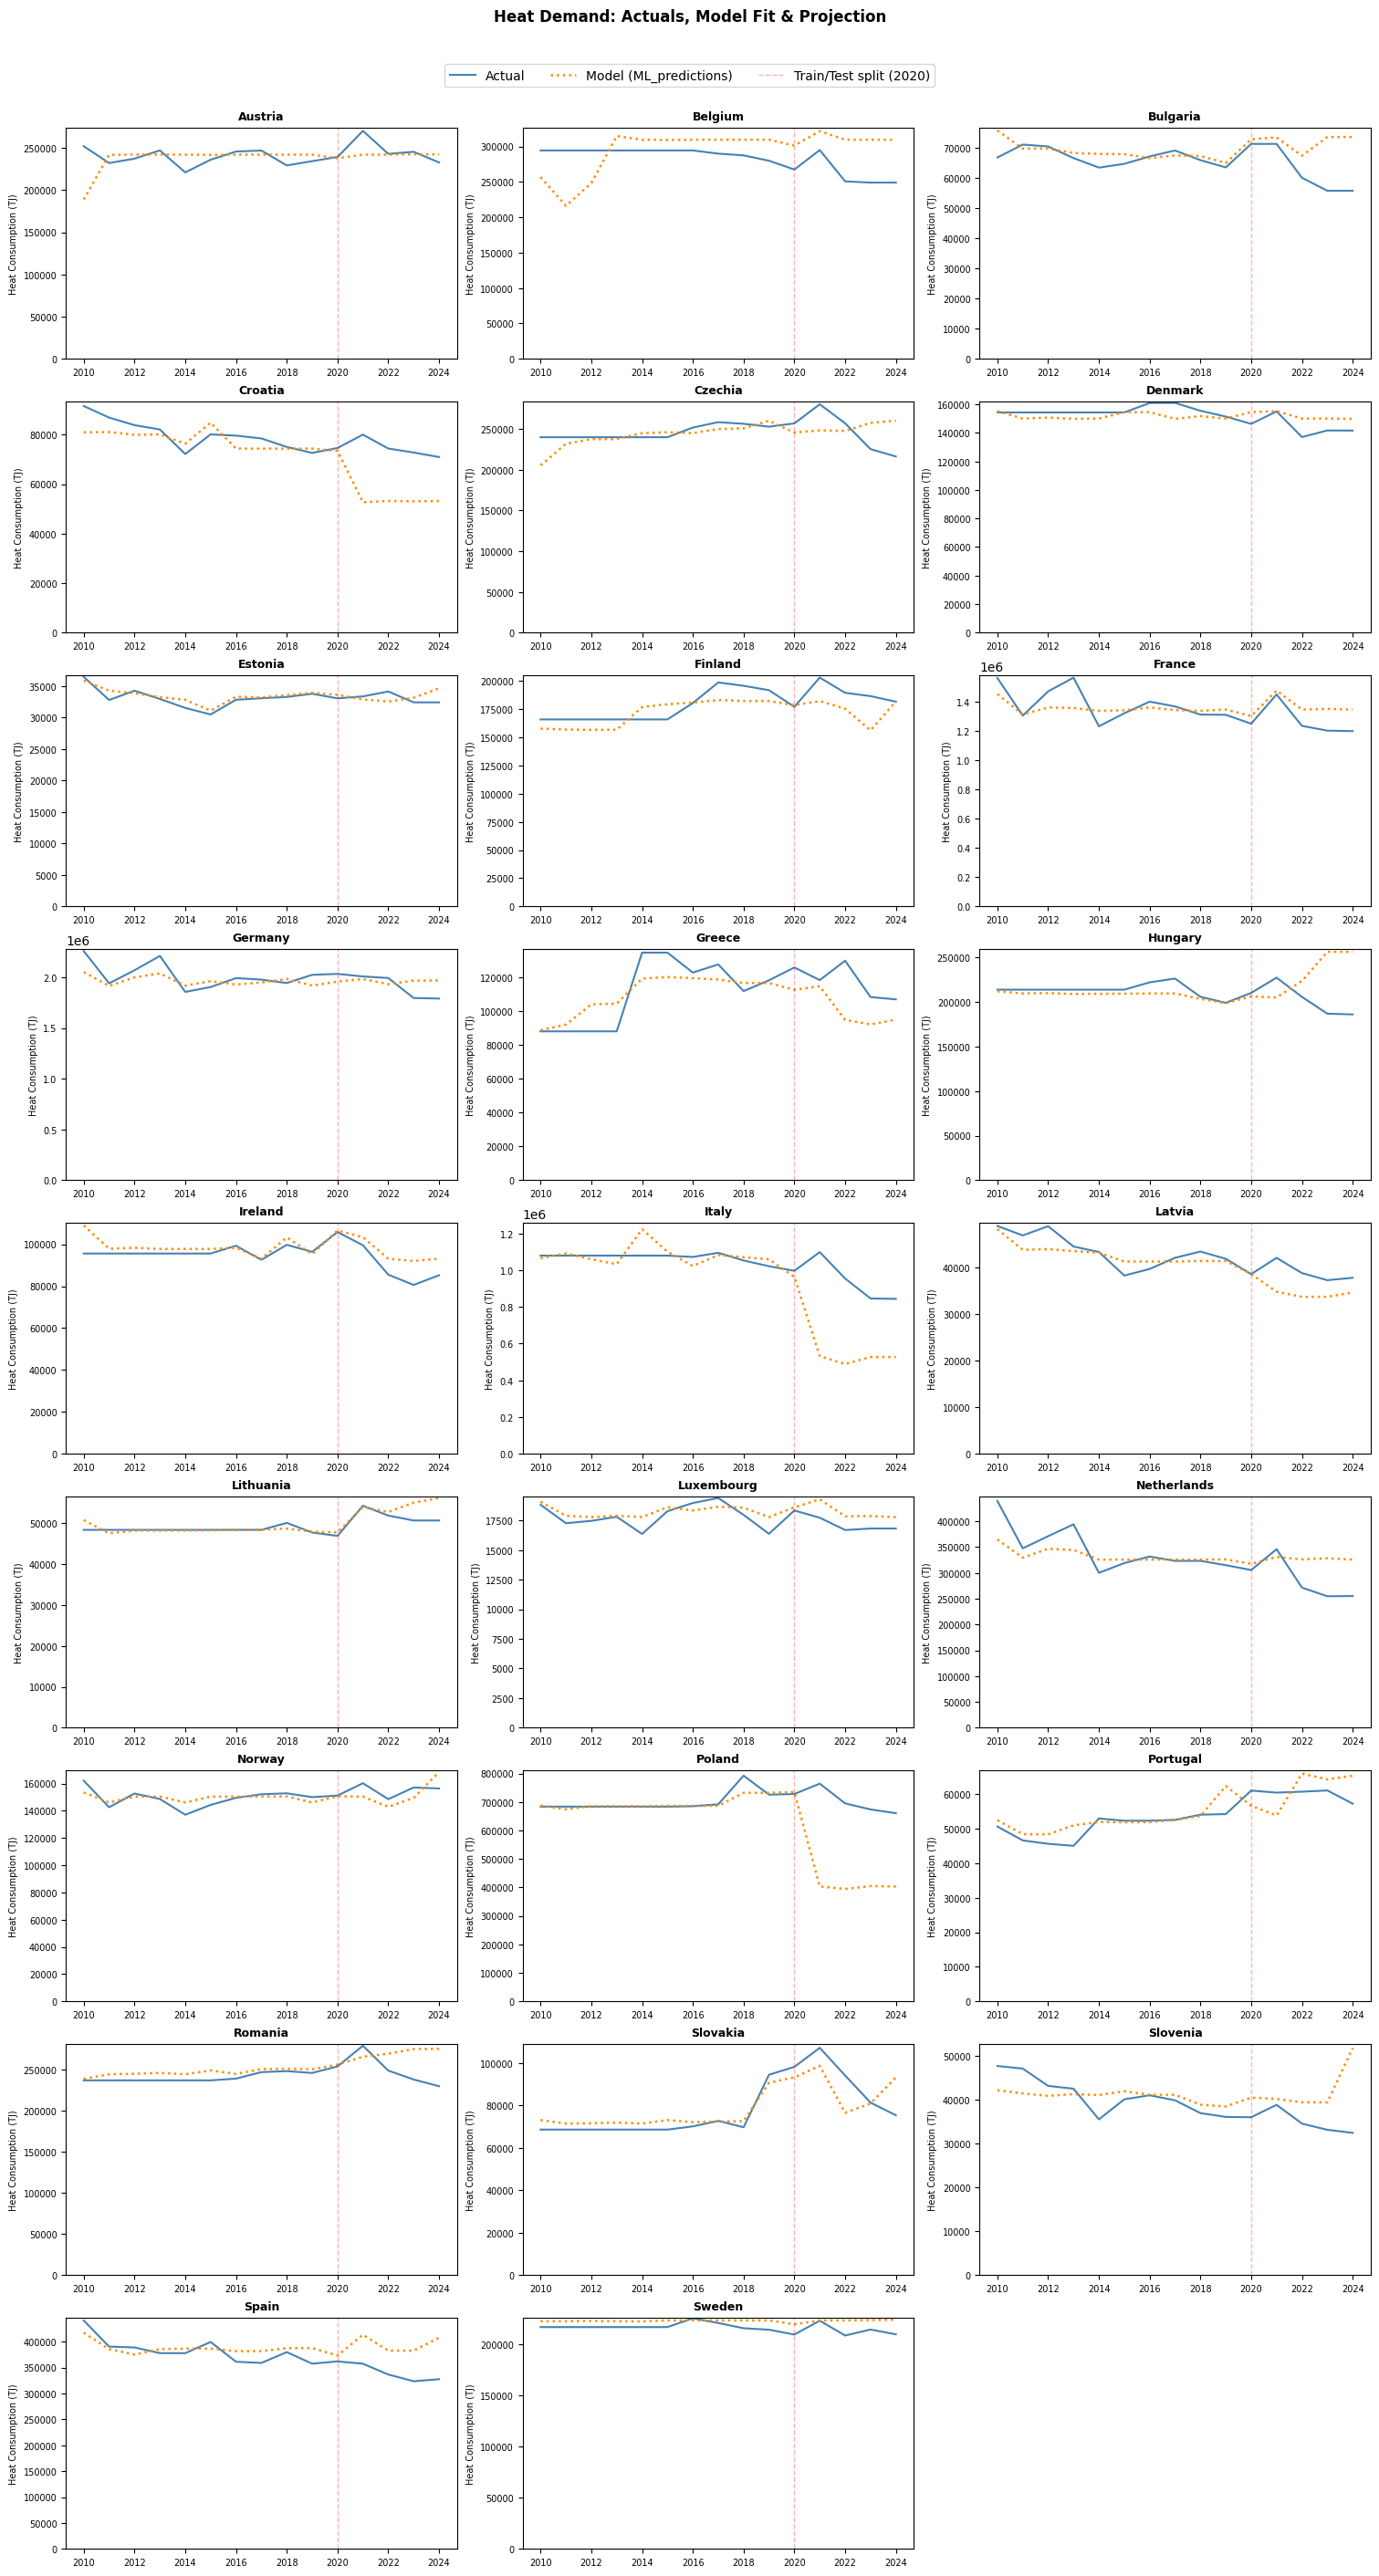

In [ ]:
X = hist_ML.drop(columns="Total_Heat_TJ")
X.country = X.country.astype('category')

y = hist_ML["Total_Heat_TJ"]

categorical = ["country"]
numeric = FEATURES

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    #("cat", LabelEncoder(), categorical),
    ("num", "passthrough", numeric)
])

"""# XGBRegressor model
model = Pipeline([
    ("prep", preprocessor),
    ("rf", XGBRegressor(n_estimators=150, 
                        learning_rate=0.05,
                        random_state=42,
                        max_depth=3,
                        ))
])
"""
"""model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestRegressor(n_estimators=500,
                        random_state=42,
                        max_depth=5,
                        ))
])"""

# XGBRegressor model with activation function: "log"
pipe = Pipeline([
    ("prep", preprocessor),
    ("rf", XGBRegressor(n_estimators=200,
                        learning_rate=0.05,
                        max_depth=3,
                        random_state=42))
])

model = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1
)



YEAR_TEST_VAL = 2020
X_train = X[X.year <= YEAR_TEST_VAL]
X_test = X[X.year > YEAR_TEST_VAL]
y_train = y[X_train.index]
y_test = y[X_test.index]
"""X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)"""


model.fit(X_train, y_train)

hist_ML["ML_predictions"] = model.predict(X)
proj_ML["Total_Heat_TJ_ML"] = model.predict(proj_ML)

# plotting the results of ML model
plot_heat_demand(
    hist=hist_ML.set_index(["country", "year"]),
    proj=proj_ML.set_index(["country", "year"]),
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="ML_predictions",      # column added in the prediction cell above
    #proj_pred_col="Total_Heat_TJ_ML",          # change to "Total_Heat_TJ_ML" when ready
    proj_pred_col=None,
    #test_split_year=None,
)

orig_train_pred = model.predict(X_train)
orig_test_pred  = model.predict(X_test)

print("=== Original model ===")
report_metrics("TRAIN",    y_train, orig_train_pred)
report_metrics("TEST",     y_test,  orig_test_pred)
print()

## Forecasting the future with all historical data with XGBRegressor

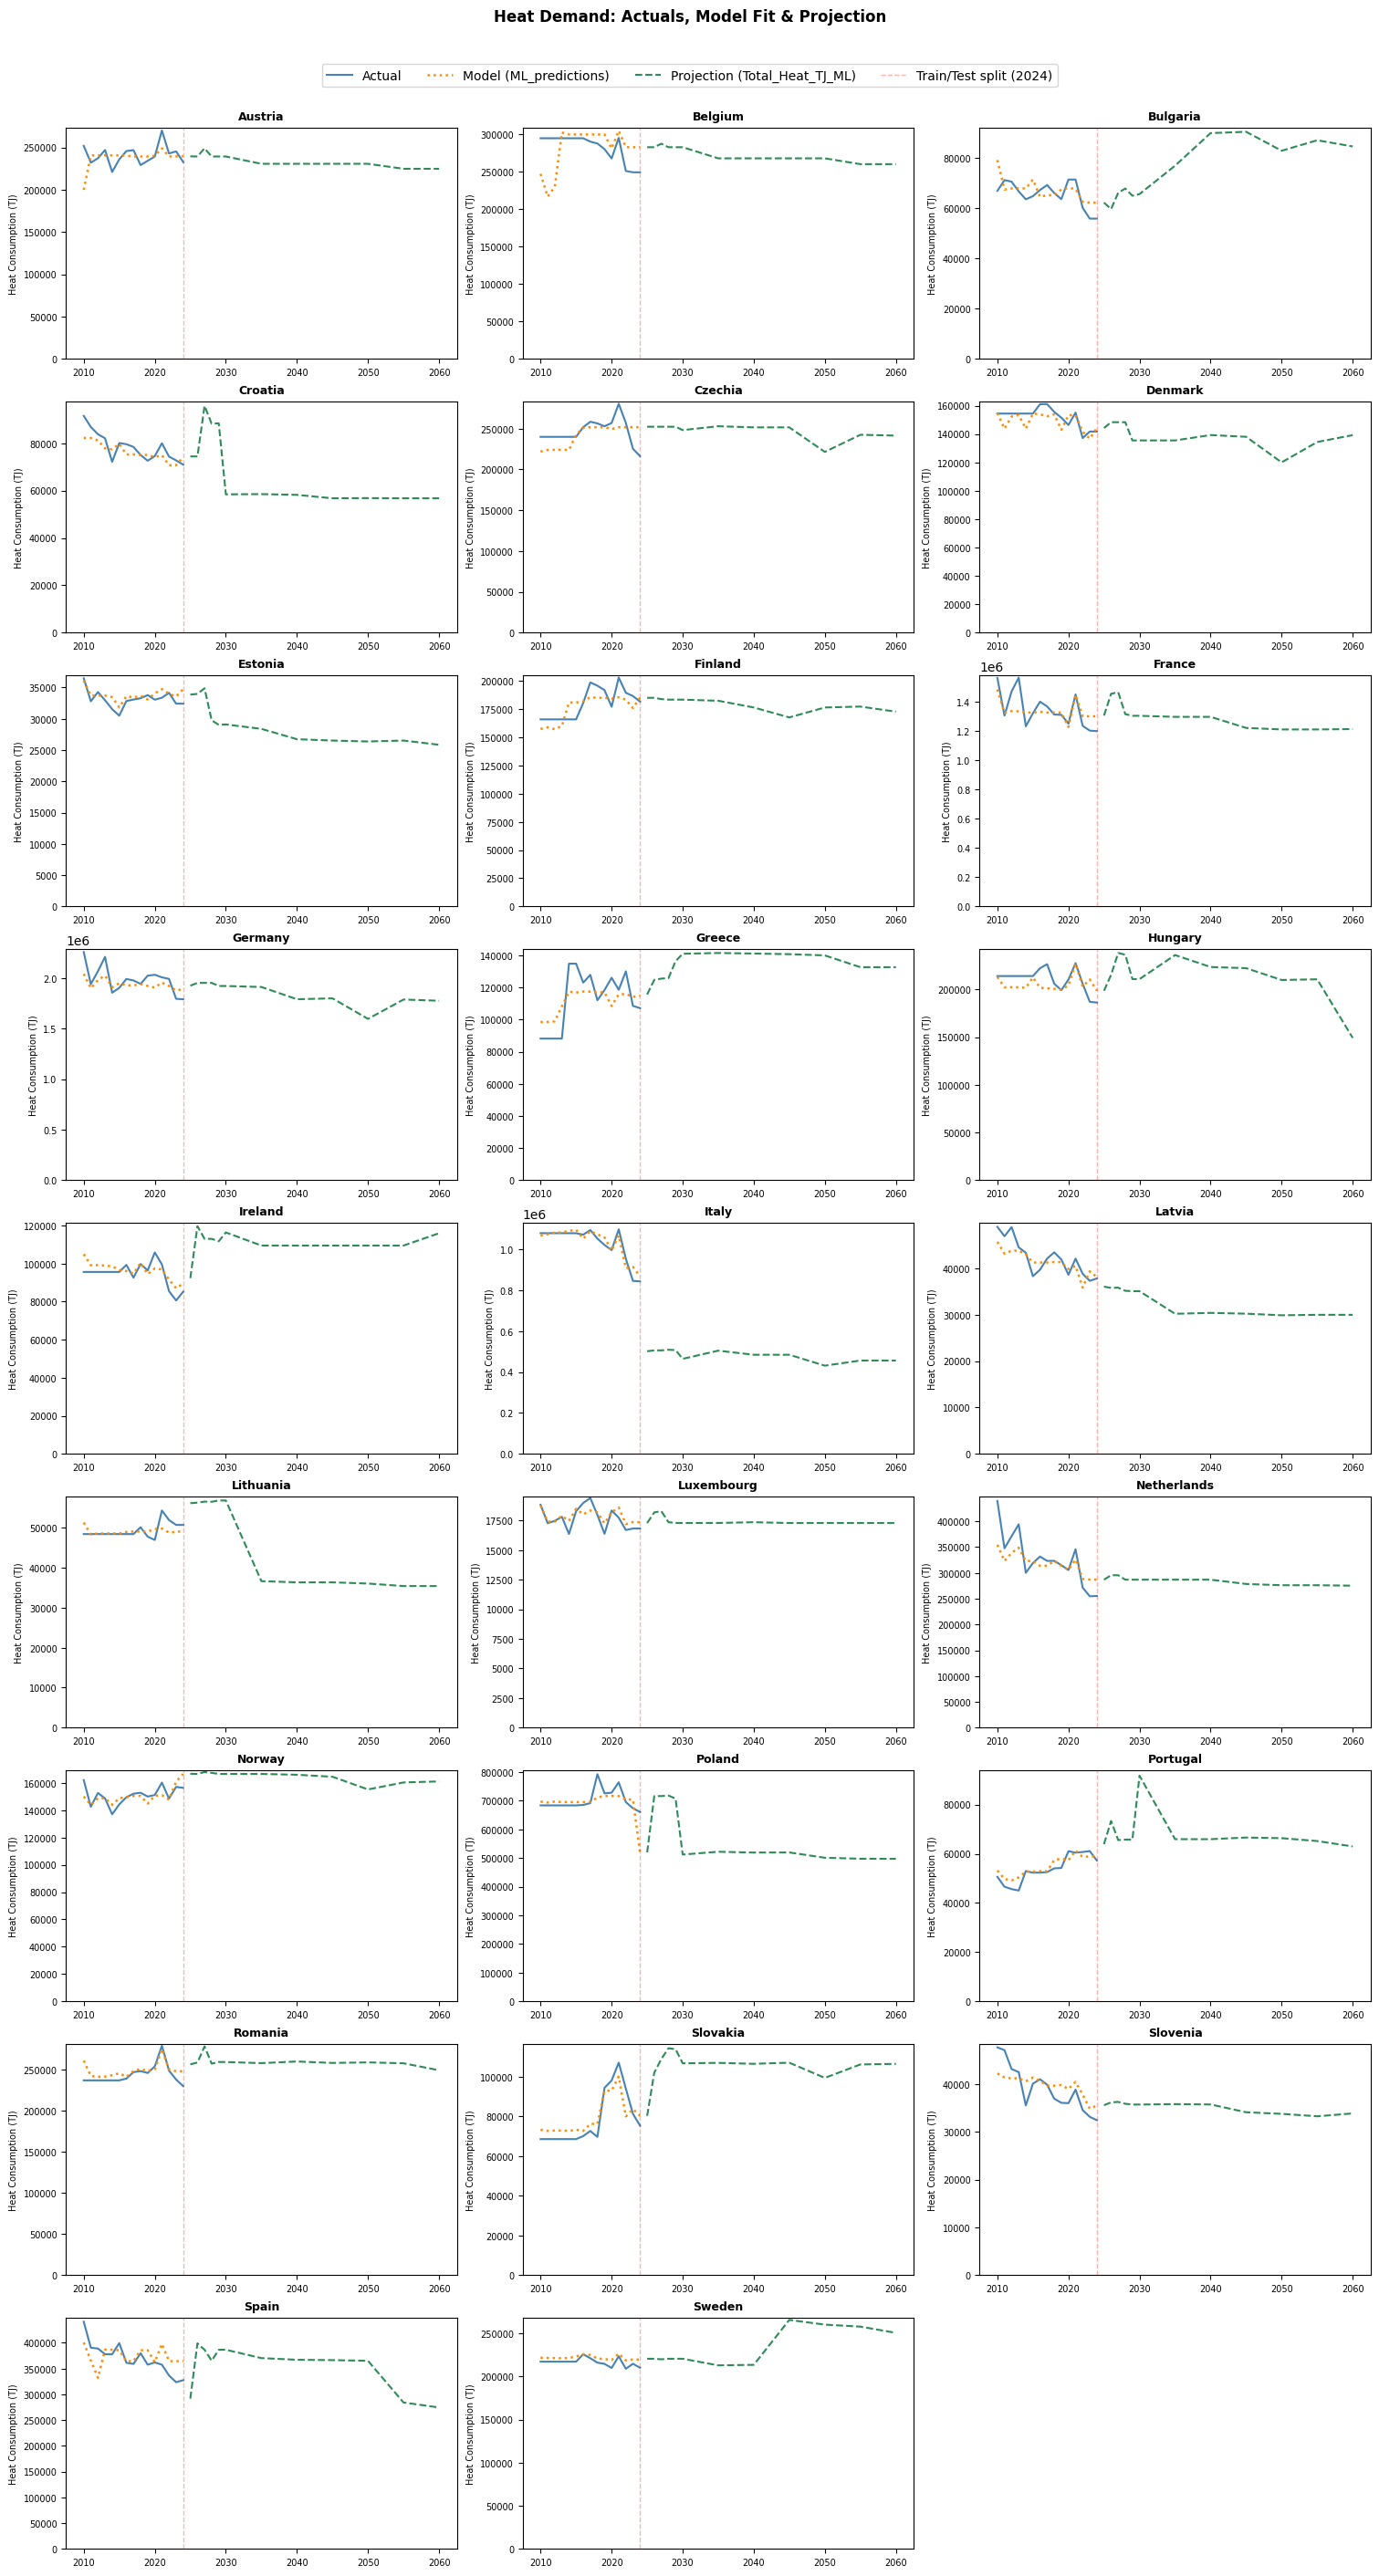

In [ ]:
model.fit(X, y)

#model.fit(X_train, y_train)

hist_ML["ML_predictions"] = model.predict(X)
proj_ML["Total_Heat_TJ_ML"] = model.predict(proj_ML)

# plotting the results of ML model
plot_heat_demand(
    hist=hist_ML.set_index(["country", "year"]),
    proj=proj_ML.set_index(["country", "year"]),
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="ML_predictions",      # column added in the prediction cell above
    proj_pred_col="Total_Heat_TJ_ML",          # change to "Total_Heat_TJ_ML" when ready
    test_split_year=2024
)

In [ ]:
proj_ML

,country,year,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,Total_Heat_TJ_ML
0,Austria,2025,9.197213,62963.14442,-0.036296,3379.147461,239536.453125
1,Belgium,2025,11.883495,63587.69763,1.156512,2096.058322,282488.406250
2,Bulgaria,2025,6.437360,35153.67259,2.927476,2362.448733,62228.753906
3,Croatia,2025,3.874350,44491.65593,3.896182,1798.925031,74424.515625
4,Czechia,2025,10.909500,48882.03249,2.120203,2848.255319,252411.484375
...,...,...,...,...,...,...,...
307,Romania,2060,16.333523,72256.62000,1.007720,2543.820865,249323.328125
308,Slovakia,2060,4.850265,69326.40000,0.888031,2855.311013,106544.898438
309,Slovenia,2060,2.047613,81846.32000,1.617258,2240.830881,33875.800781
310,Spain,2060,53.468132,75910.47000,1.517263,1176.424436,274484.718750


# ML Model-Feature Engineering

In [ ]:
# add interaction & combined features to both dataframes
for df in [hist_ML, proj_ML]:
    df["gdp_total"]     = df["population_Mio"] * df["gdp_per_capita_USD"] / 1000  # total GDP [B USD]
    df["hdd_x_pop"]     = df["hdd_DegreesC"]   * df["population_Mio"]             # heating load × population


FEATURES_ENG = FEATURES + ["gdp_total", "hdd_x_pop"]

In [ ]:
"""X = hist_ML.drop(columns="Total_Heat_TJ")
X.country = X.country.astype('category')

y = hist_ML["Total_Heat_TJ"]

categorical = ["country"]
numeric = FEATURES_ENG

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    #("cat", LabelEncoder(), categorical),
    ("num", "passthrough", numeric)
])

# XGBRegressor model with activation function: "log"
pipe = Pipeline([
    ("prep", preprocessor),
    ("rf", XGBRegressor(n_estimators=200,
                        learning_rate=0.05,
                        max_depth=3,
                        random_state=42))
])

model = TransformedTargetRegressor(
    regressor=pipe,
    func=np.log1p,
    inverse_func=np.expm1
)



YEAR_TEST_VAL = 2020
X_train = X[X.year <= YEAR_TEST_VAL]
X_test = X[X.year > YEAR_TEST_VAL]
y_train = y[X_train.index]
y_test = y[X_test.index]


model.fit(X_train, y_train)

hist_ML["ML_predictions"] = model.predict(X)
proj_ML["Total_Heat_TJ_ML"] = model.predict(proj_ML)

# plotting the results of ML model
plot_heat_demand(
    hist=hist_ML.set_index(["country", "year"]),
    proj=proj_ML.set_index(["country", "year"]),
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="ML_predictions",      # column added in the prediction cell above
    #proj_pred_col="Total_Heat_TJ_ML",          # change to "Total_Heat_TJ_ML" when ready
    proj_pred_col=None,
    #test_split_year=None,
)

orig_train_pred = model.predict(X_train)
orig_test_pred  = model.predict(X_test)
orig_hist_pred = model.predict(X)

print("=== Original model ===")
report_metrics("TRAIN",    y_train, orig_train_pred)
report_metrics("TEST",     y_test,  orig_test_pred)
report_metrics("HIST",      y,       orig_hist_pred)
print()"""

'X = hist_ML.drop(columns="Total_Heat_TJ")\nX.country = X.country.astype(\'category\')\n\ny = hist_ML["Total_Heat_TJ"]\n\ncategorical = ["country"]\nnumeric = FEATURES_ENG\n\npreprocessor = ColumnTransformer([\n    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),\n    #("cat", LabelEncoder(), categorical),\n    ("num", "passthrough", numeric)\n])\n\n# XGBRegressor model with activation function: "log"\npipe = Pipeline([\n    ("prep", preprocessor),\n    ("rf", XGBRegressor(n_estimators=200,\n                        learning_rate=0.05,\n                        max_depth=3,\n                        random_state=42))\n])\n\nmodel = TransformedTargetRegressor(\n    regressor=pipe,\n    func=np.log1p,\n    inverse_func=np.expm1\n)\n\n\n\nYEAR_TEST_VAL = 2020\nX_train = X[X.year <= YEAR_TEST_VAL]\nX_test = X[X.year > YEAR_TEST_VAL]\ny_train = y[X_train.index]\ny_test = y[X_test.index]\n\n\nmodel.fit(X_train, y_train)\n\nhist_ML["ML_predictions"] = model.predict(X)\nproj_ML["Tota

In [ ]:
"""model.fit(X, y)

#model.fit(X_train, y_train)

hist_ML["ML_predictions"] = model.predict(X)
proj_ML["Total_Heat_TJ_ML"] = model.predict(proj_ML)

# plotting the results of ML model
plot_heat_demand(
    hist=hist_ML.set_index(["country", "year"]),
    proj=proj_ML.set_index(["country", "year"]),
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="ML_predictions",      # column added in the prediction cell above
    proj_pred_col="Total_Heat_TJ_ML",          # change to "Total_Heat_TJ_ML" when ready
    test_split_year=2024
)"""

'model.fit(X, y)\n\n#model.fit(X_train, y_train)\n\nhist_ML["ML_predictions"] = model.predict(X)\nproj_ML["Total_Heat_TJ_ML"] = model.predict(proj_ML)\n\n# plotting the results of ML model\nplot_heat_demand(\n    hist=hist_ML.set_index(["country", "year"]),\n    proj=proj_ML.set_index(["country", "year"]),\n    hist_actual_col="Total_Heat_TJ",\n    hist_pred_col="ML_predictions",      # column added in the prediction cell above\n    proj_pred_col="Total_Heat_TJ_ML",          # change to "Total_Heat_TJ_ML" when ready\n    test_split_year=2024\n)'

In [ ]:
# expanding-window cross-validation by year
CV_TEST_YEARS = range(2018, 2025)

cv_rows = []
for test_year in CV_TEST_YEARS:
    X_tr = X[X.year <  test_year]
    X_te = X[X.year == test_year]
    y_tr = y.loc[X_tr.index]
    y_te = y.loc[X_te.index]

    _m = TransformedTargetRegressor(
        regressor=Pipeline([
            ("prep", ColumnTransformer([
                ("cat", OneHotEncoder(handle_unknown="ignore"), ["country"]),
                ("num", "passthrough", numeric)
            ])),
            ("rf", XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42))
        ]),
        func=np.log1p, inverse_func=np.expm1
    )
    _m.fit(X_tr, y_tr)
    preds = _m.predict(X_te)

    cv_rows.append({
        "test_year": test_year,
        "n_train":   len(X_tr),
        "MAPE_%":    mean_absolute_percentage_error(y_te, preds) * 100,
        "R2":        r2_score(y_te, preds),
    })

cv_df = pd.DataFrame(cv_rows)
print(cv_df.to_string(index=False))
print(f"\nMean  MAPE={cv_df['MAPE_%'].mean():.2f}%  R²={cv_df['R2'].mean():.4f}")

 test_year  n_train    MAPE_%       R2
      2018      208  8.104220 0.995578
      2019      234 10.142588 0.992040
      2020      260 11.019782 0.926071
      2021      286 10.711465 0.919629
      2022      312 12.805272 0.969297
      2023      338 13.312752 0.976951
      2024      364 12.380051 0.966292

Mean  MAPE=11.21%  R²=0.9637


In [ ]:
proj_ML

,country,year,population_Mio,gdp_per_capita_USD,gdp_growth_rate_Percent,hdd_DegreesC,Total_Heat_TJ_ML,gdp_total,hdd_x_pop
0,Austria,2025,9.197213,62963.14442,-0.036296,3379.147461,239536.453125,579.085450,31078.738956
1,Belgium,2025,11.883495,63587.69763,1.156512,2096.058322,282488.406250,755.644087,24908.498589
2,Bulgaria,2025,6.437360,35153.67259,2.927476,2362.448733,62228.753906,226.296846,15207.932979
3,Croatia,2025,3.874350,44491.65593,3.896182,1798.925031,74424.515625,172.376247,6969.665193
4,Czechia,2025,10.909500,48882.03249,2.120203,2848.255319,252411.484375,533.278533,31073.041399
...,...,...,...,...,...,...,...,...,...
307,Romania,2060,16.333523,72256.62000,1.007720,2543.820865,249323.328125,1180.205165,41549.556603
308,Slovakia,2060,4.850265,69326.40000,0.888031,2855.311013,106544.898438,336.251411,13849.015072
309,Slovenia,2060,2.047613,81846.32000,1.617258,2240.830881,33875.800781,167.589589,4588.354444
310,Spain,2060,53.468132,75910.47000,1.517263,1176.424436,274484.718750,4058.791030,62901.217019


# Calculating Heat Pump Demand

In [ ]:
hp_shares_hist = nrg_d_hhq_heating[nrg_d_hhq_heating.carrier == "Ambient heat (heat pumps)"]
hp_shares_hist = hp_shares_hist[["country", "year", "share_pu"]]

# filling the last value for Bulgaria
hp_shares_hist.loc[
    (hp_shares_hist["country"] == "Bulgaria") & 
    (hp_shares_hist["year"] == 2024), 
    "share_pu"
] = 0

hp_shares_hist[hp_shares_hist.country == "Lithuania"]

,country,year,share_pu
223,Lithuania,2010,NaN
224,Lithuania,2011,NaN
225,Lithuania,2012,NaN
226,Lithuania,2013,NaN
227,Lithuania,2014,NaN
228,Lithuania,2015,NaN
229,Lithuania,2016,NaN
230,Lithuania,2017,0.000000
231,Lithuania,2018,0.018591
232,Lithuania,2019,0.020451


In [ ]:
# year when max share is reached, and what fraction of max is the target
SCENARIOS = {
    "KKO": {"target_year": 2045, "target_fraction": 1.00},
    "KVE": {"target_year": 2050, "target_fraction": 1.00},
    "VWE": {"target_year": 2060, "target_fraction": 1.00},
    "VNI": {"target_year": 2060, "target_fraction": 0.75},
}

## Building share projections per scenario (S-Curve) --> hp_shares_proj
Adoption follows a **logistic (sigmoid) curve**: slow initial uptake, rapid acceleration through the middle years, then saturation near the target — typical technology diffusion pattern (Bass / S-Kurve).

The inflection point is set at the midpoint between 2024 and the scenario target year. Steepness `k = 6 / duration` places the curve at ~5 % progress in 2024 and ~95 % progress at the target year, with the interpolated values normalized to exactly 0 → 1.

In [ ]:
# Building share projections per scenario --> hp_shares_proj
# The development of heat pump shares follows a logistic S-curve (technology diffusion)
PROJ_YEARS = list(range(2025, 2061))

def project_hp_share_scurve(country, scenario_name):
    params          = SCENARIOS[scenario_name]
    target_year     = params["target_year"]
    target_fraction = params["target_fraction"]

    # starting share = last known historical value (2024)
    start_share = (hp_shares_hist
                   .loc[hp_shares_hist["country"] == country, :]
                   .sort_values("year")
                   ["share_pu"]
                   .iloc[-1])

    # target share = fraction of max possible
    end_share = max_hp_share[country] * target_fraction

    # sigmoid parameters: inflection at midpoint, k chosen so curve spans ~5%–95% over the period
    duration  = target_year - 2024
    t_mid     = 2024 + duration / 2
    k         = 6 / duration

    # normalize so progress = 0 at t=2024 and progress = 1 at t=target_year
    sig_start = 1 / (1 + np.exp(-k * (2024        - t_mid)))
    sig_end   = 1 / (1 + np.exp(-k * (target_year - t_mid)))

    rows = []
    for year in PROJ_YEARS:
        if year >= target_year:
            share = end_share
        else:
            sig_t    = 1 / (1 + np.exp(-k * (year - t_mid)))
            progress = (sig_t - sig_start) / (sig_end - sig_start)
            share    = start_share + progress * (end_share - start_share)

        rows.append({"country": country, "year": year,
                     "scenario": scenario_name, "share_pu": share})
    return rows


# build full projection dataframe
all_rows = []
for scenario in SCENARIOS:
    for country in max_hp_share.index:
        all_rows.extend(project_hp_share_scurve(country, scenario))

hp_shares_proj = pd.DataFrame(all_rows)
#print(hp_shares_proj.head(20).to_string())
#print(f"\nShape: {hp_shares_proj.shape}")
hp_shares_proj[hp_shares_proj.country == "Lithuania"]

,country,year,scenario,share_pu
540,Lithuania,2025,KKO,0.085665
541,Lithuania,2026,KKO,0.087582
542,Lithuania,2027,KKO,0.090015
543,Lithuania,2028,KKO,0.093064
544,Lithuania,2029,KKO,0.096816
...,...,...,...,...
3379,Lithuania,2056,VNI,0.129857
3380,Lithuania,2057,VNI,0.130520
3381,Lithuania,2058,VNI,0.131095
3382,Lithuania,2059,VNI,0.131593


In [ ]:
# Building share projections per scenario --> hp_shares_proj_linear  (kept for reference)
# The development of heat pump shares are linear
def project_hp_share(country, scenario_name):
    params          = SCENARIOS[scenario_name]
    target_year     = params["target_year"]
    target_fraction = params["target_fraction"]

    # starting share = last known historical value (2024)
    start_share = (hp_shares_hist
                   .loc[hp_shares_hist["country"] == country, :]
                   .sort_values("year")
                   ["share_pu"]
                   .iloc[-1])

    # target share = fraction of max possible
    end_share = max_hp_share[country] * target_fraction

    rows = []
    for year in PROJ_YEARS:
        if year >= target_year:
            share = end_share
        else:
            # linear interpolation between 2024 and target_year
            progress = (year - 2024) / (target_year - 2024)
            share    = start_share + progress * (end_share - start_share)

        rows.append({"country": country, "year": year,
                     "scenario": scenario_name, "share_pu": share})
    return rows


# build full projection dataframe
all_rows = []
for scenario in SCENARIOS:
    for country in max_hp_share.index:
        all_rows.extend(project_hp_share(country, scenario))

hp_shares_proj_linear = pd.DataFrame(all_rows)
#print(hp_shares_proj_linear.head(20).to_string())
#print(f"\nShape: {hp_shares_proj_linear.shape}")
hp_shares_proj_linear[hp_shares_proj_linear.country == "Lithuania"]

,country,year,scenario,share_pu
540,Lithuania,2025,KKO,0.088547
541,Lithuania,2026,KKO,0.092921
542,Lithuania,2027,KKO,0.097295
543,Lithuania,2028,KKO,0.101669
544,Lithuania,2029,KKO,0.106043
...,...,...,...,...
3379,Lithuania,2056,VNI,0.126706
3380,Lithuania,2057,VNI,0.128035
3381,Lithuania,2058,VNI,0.129364
3382,Lithuania,2059,VNI,0.130693


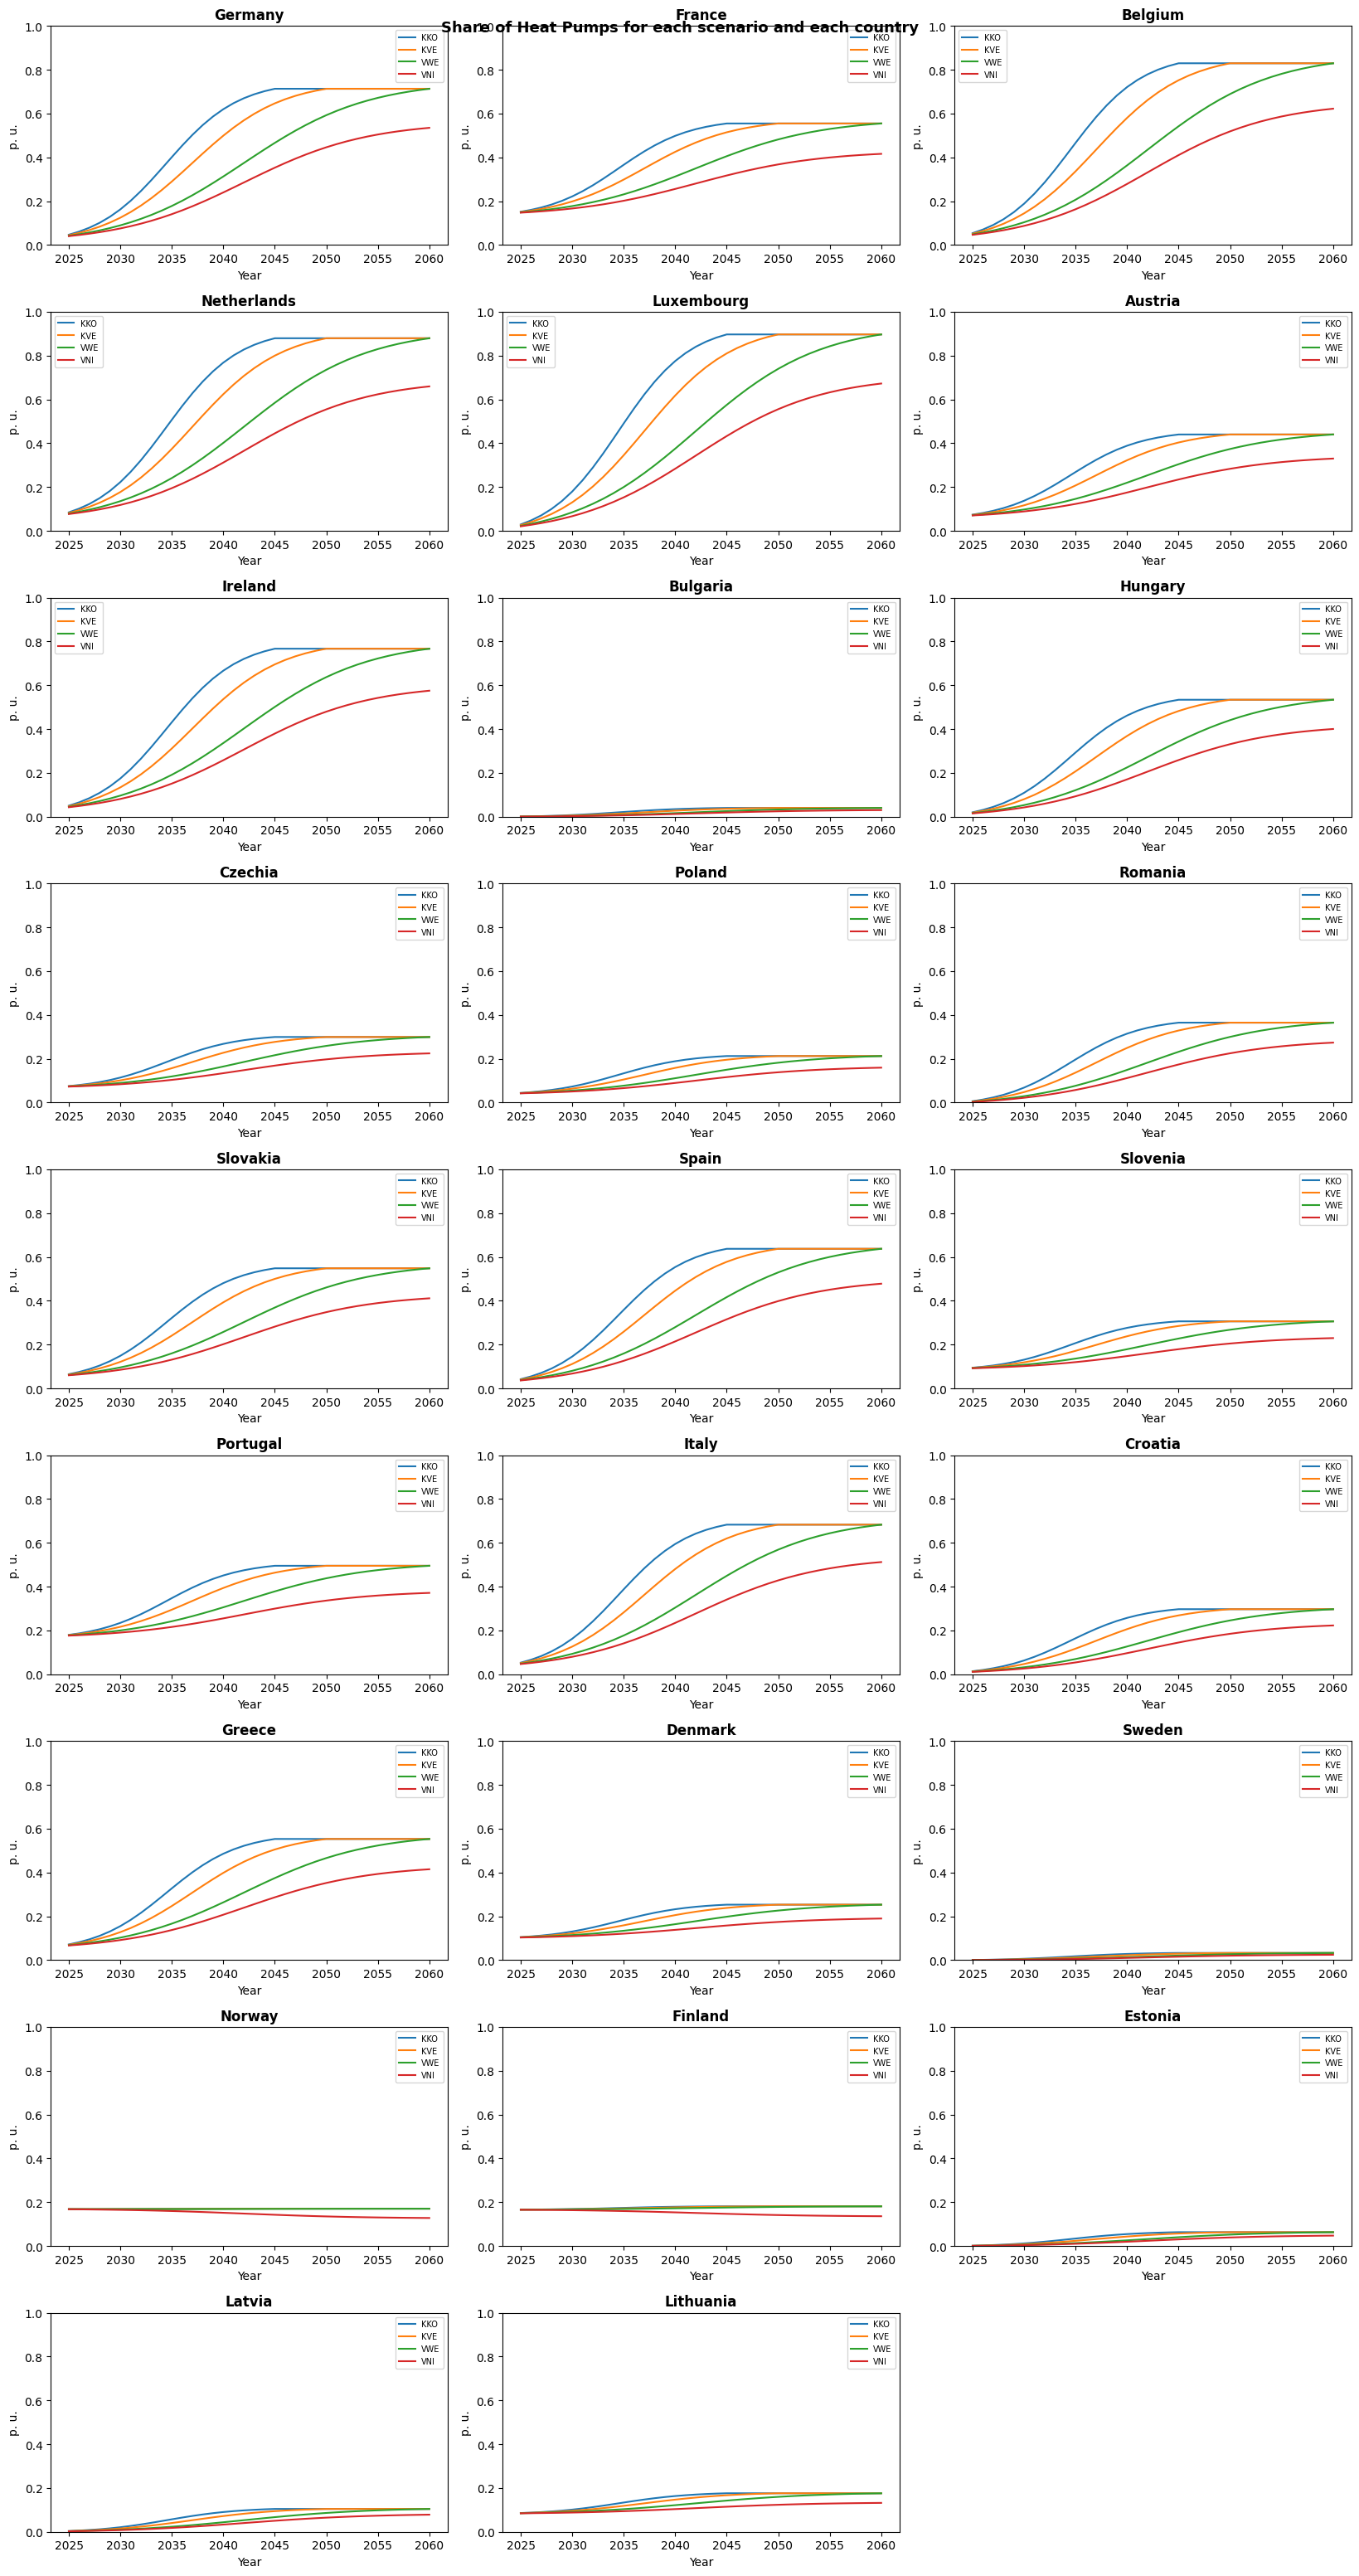

In [ ]:
import matplotlib.pyplot as plt
import math

PROJECTION = hp_shares_proj # or hp_shares_proj_linear or hp_shares_proj

n_cols = 3
n_rows = math.ceil(len(ALL_COUNTRIES) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5.5, n_rows * 3.5))
axes = axes.flatten()

for ax, country in zip(axes, ALL_COUNTRIES):
    for scenario in SCENARIOS:
        d = PROJECTION[
            (PROJECTION["country"]  == country) &
            (PROJECTION["scenario"] == scenario)
        ]
        ax.plot(d["year"], d["share_pu"], label=scenario)

    ax.set_title(country, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("p. u.")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.0)

# hide unused subplots
for ax in axes[len(ALL_COUNTRIES):]:
    ax.set_visible(False)

plt.suptitle("Share of Heat Pumps for each scenario and each country",
             fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("Results/HP_electricity_demand_2025_2060.png", dpi=300)
plt.show()

## calculate HP electricity demand

In [ ]:
PROJ_YEARS = [2025, 2026, 2027, 2028, 2029, 2030,
              2035, 2040, 2045, 2050, 2055, 2060]

# COP by country group (from Rivière et al. 2009)
#Southern Europe  & ES, PT, IT, GR, HR, SI & 4.3 
#Western/Central  & FR, DE, AT, BE, NL, LU, IE & 4.0
#Eastern Europe   & PL, CZ, SK, HU, RO, BG & 3.5 
#Nordic/Baltic    & SE, FI, NO, DK, EE, LV, LT & 3.3 

COP_MAP = {
    "Austria": 4.0, "Belgium": 4.0, "Bulgaria": 3.5, "Croatia": 4.3,
    "Czechia": 3.5, "Denmark": 3.3, "Estonia": 3.3, "Finland": 3.3,
    "France": 4.0,  "Germany": 4.0, "Greece": 4.3,  "Hungary": 3.5,
    "Ireland": 4.0, "Italy": 4.0,   "Latvia": 3.3,  "Lithuania": 3.3,
    "Luxembourg": 4.0, "Netherlands": 4.0, "Norway": 3.3, "Poland": 3.5,
    "Portugal": 4.3,   "Romania": 3.5,    "Slovakia": 3.5, "Slovenia": 4.3,
    "Spain": 4.3,      "Sweden": 3.3,
}

# service sector multiplier (HP demand in services on top of residential)
#SERVICE_MULTIPLIER = 1.25
SERVICE_MULTIPLIER = 1

# merge projection shares with total heat demand from ML model
proj_heat = proj_ML[["country", "year", "Total_Heat_TJ_ML"]].copy()

hp_demand_proj = hp_shares_proj.merge(proj_heat,
                                       on=["country", "year"],
                                       how="left")

hp_demand_proj["COP"] = hp_demand_proj["country"].map(COP_MAP)

# formula: Demand_HP (TWh) = Heat(TJ) * (1/3600) * share_HP / (COP-1) * 1.25
hp_demand_proj["Demand_HP_TWh"] = (
    hp_demand_proj["Total_Heat_TJ_ML"]
    * (1 / 3600)
    * hp_demand_proj["share_pu"]
    #/ (hp_demand_proj["COP"] - 1)
    / (hp_demand_proj["COP"])
    * SERVICE_MULTIPLIER
)

#print(hp_demand_proj.head(20).to_string())
#print(f"\nShape: {hp_demand_proj.shape}")
hp_demand_proj = hp_demand_proj[hp_demand_proj.year.isin(PROJ_YEARS)]
hp_demand_proj = hp_demand_proj.reset_index(drop=True)
hp_demand_proj#[hp_demand_proj.country=="Bulgaria"]

,country,year,scenario,share_pu,Total_Heat_TJ_ML,COP,Demand_HP_TWh
0,Austria,2025,KKO,0.073984,239536.453125,4.0,1.230686
1,Austria,2026,KKO,0.081747,239343.265625,4.0,1.358718
2,Austria,2027,KKO,0.091605,249028.187500,4.0,1.584175
3,Austria,2028,KKO,0.103951,239343.265625,4.0,1.727782
4,Austria,2029,KKO,0.119151,239343.265625,4.0,1.980420
...,...,...,...,...,...,...,...
1243,Sweden,2040,VNI,0.009997,213422.812500,3.3,0.179596
1244,Sweden,2045,VNI,0.015537,265526.906250,3.3,0.347257
1245,Sweden,2050,VNI,0.020101,260037.015625,3.3,0.439984
1246,Sweden,2055,VNI,0.022960,257743.109375,3.3,0.498136


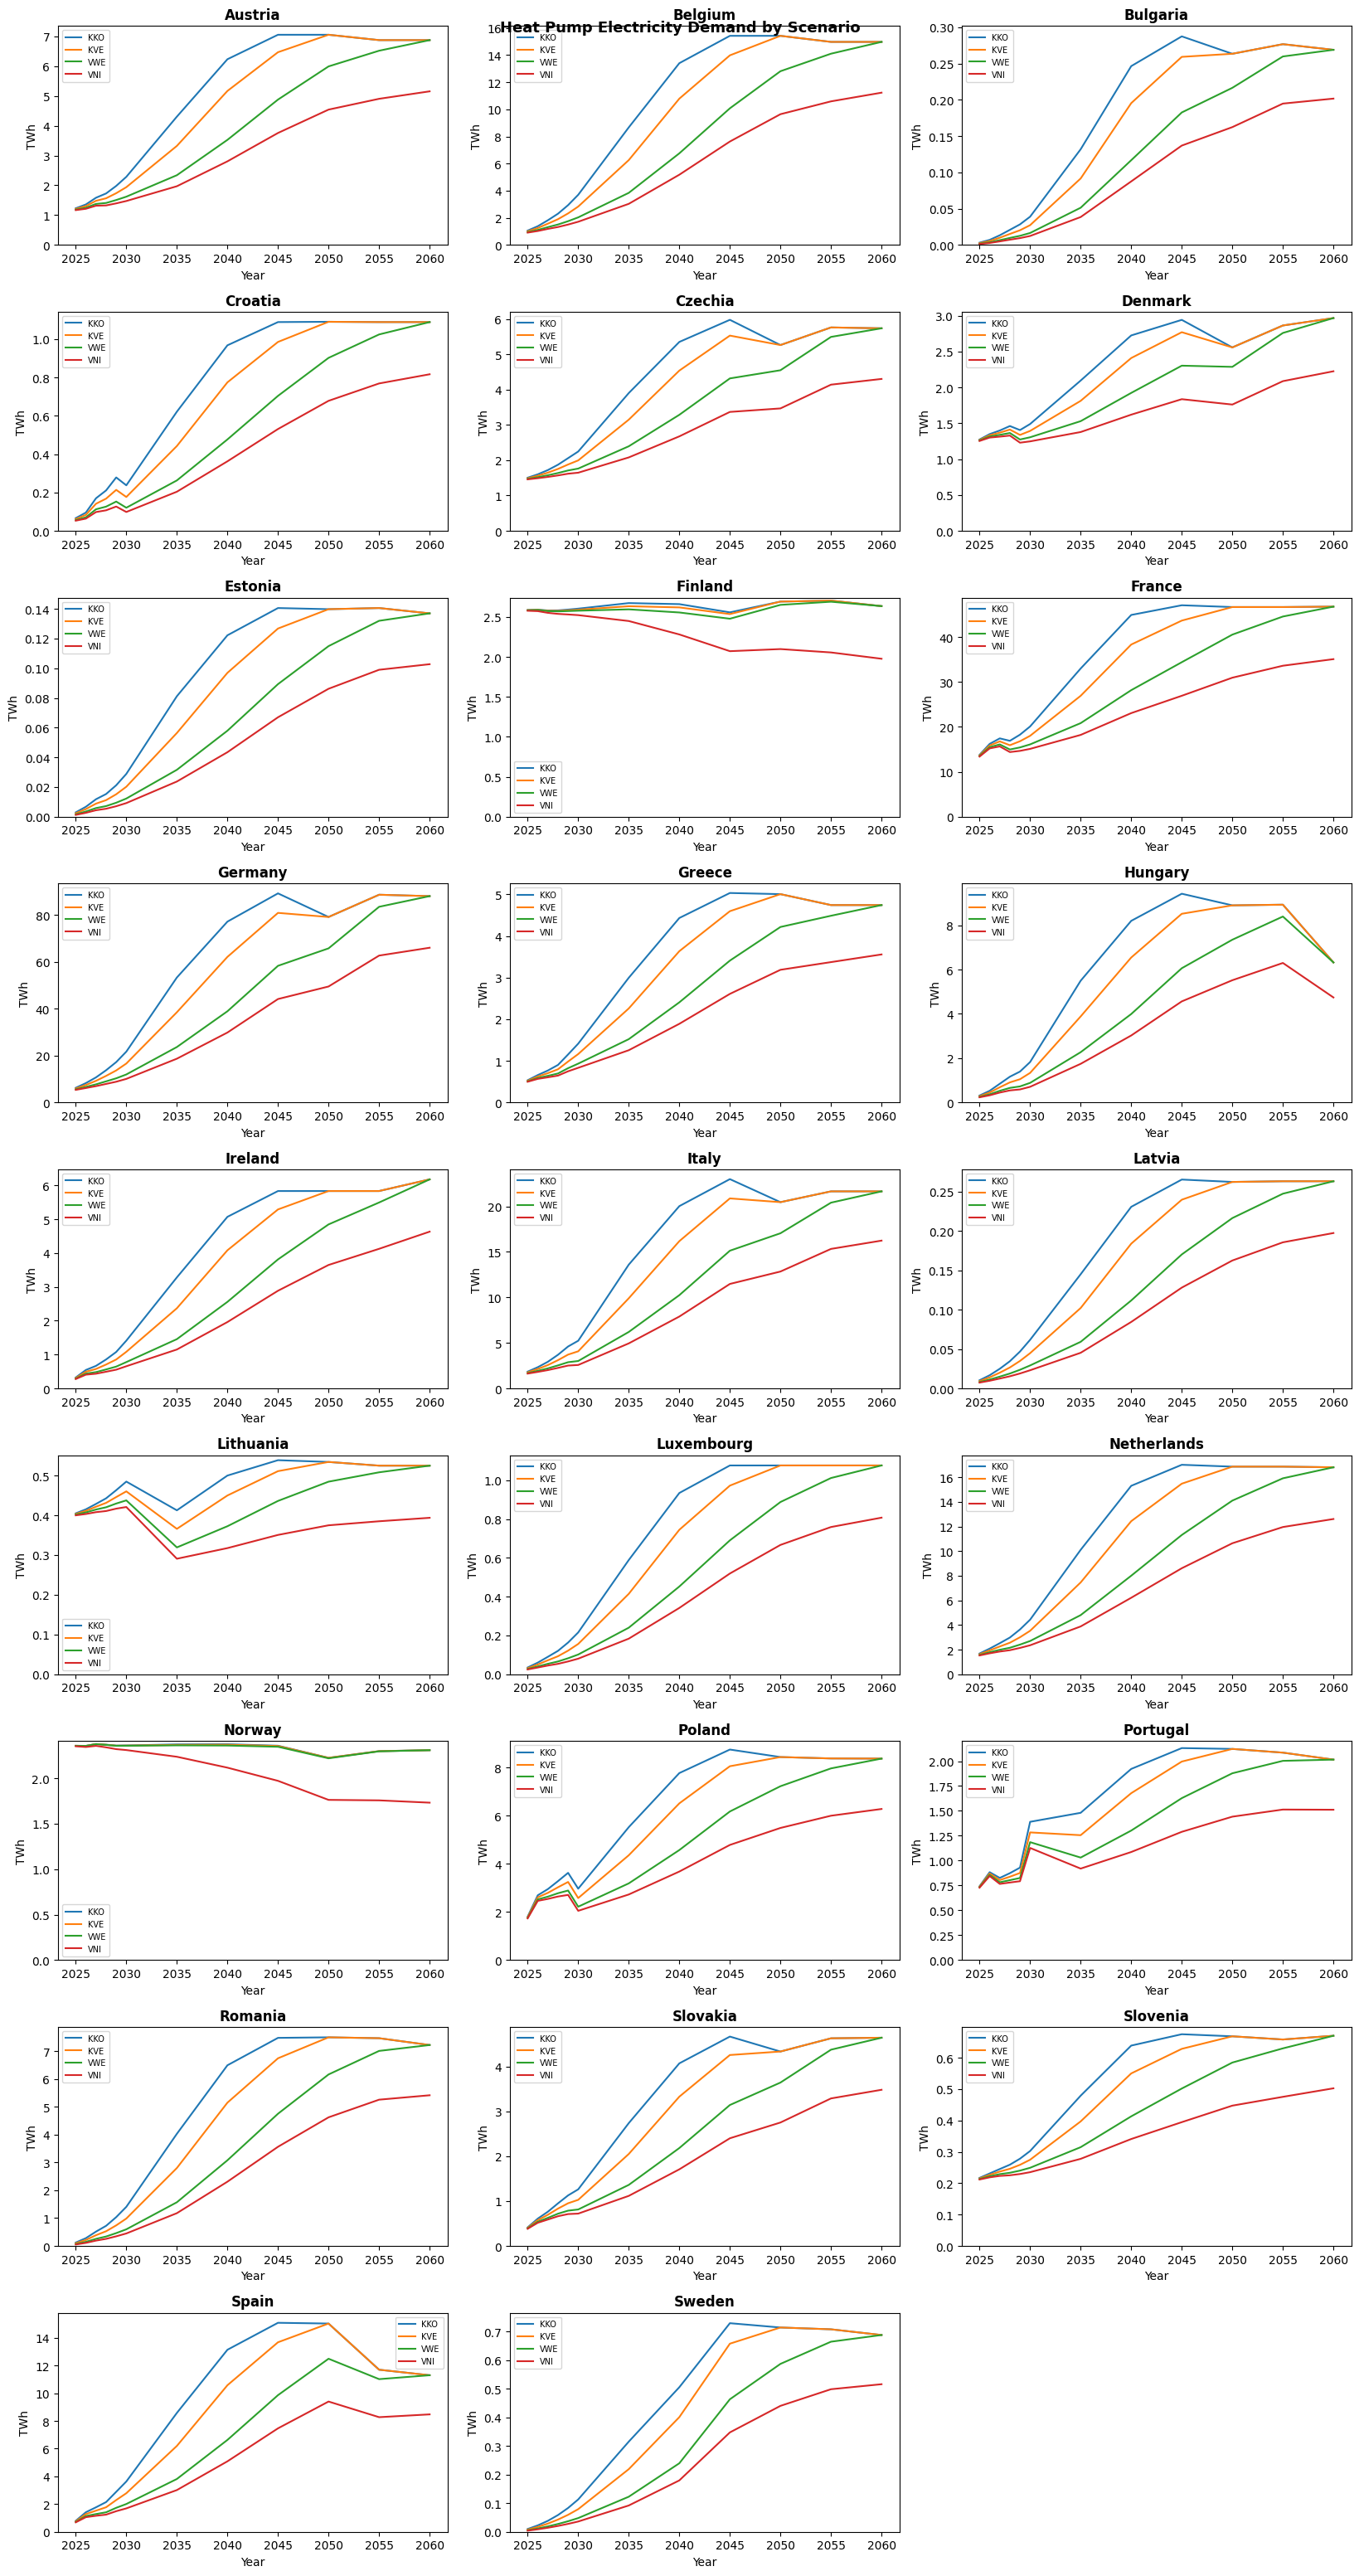

In [ ]:
import matplotlib.pyplot as plt
import math

CHECK_COUNTRIES = ALL_COUNTRIES   # or any list of countries
#CHECK_COUNTRIES = ["Bulgaria"]

CHECK_COUNTRIES = sorted(CHECK_COUNTRIES)

n_cols = 3
n_rows = math.ceil(len(CHECK_COUNTRIES) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5.5, n_rows * 3.5))
axes = axes.flatten()

for ax, country in zip(axes, CHECK_COUNTRIES):
    for scenario in SCENARIOS:
        d = hp_demand_proj[
            (hp_demand_proj["country"]  == country) &
            (hp_demand_proj["scenario"] == scenario)
        ]
        ax.plot(d["year"], d["Demand_HP_TWh"], label=scenario)

    ax.set_title(country, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("TWh")
    ax.legend(fontsize=7)
    ax.set_ylim(0, )

# hide unused subplots
for ax in axes[len(CHECK_COUNTRIES):]:
    ax.set_visible(False)

plt.suptitle("Heat Pump Electricity Demand by Scenario",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Results/HP_electricity_demand_2025_2060.png", dpi=300)
plt.show()


In [ ]:
# Saving the hp_demand_proj file as my results
hp_demand_proj.to_csv("Results/hp_demand_2025_2060.csv")

In [ ]:
hp_demand_pivoted = hp_demand_proj.pivot(index={"country", "scenario"}, columns="year", values="Demand_HP_TWh")
hp_demand_pivoted.to_excel("Results/hp_demand_2025_2060_pivoted.xlsx")

In [ ]:
# Fix for Finland & Norway:
# They have already reached their max share in 2024! and the max share calculated for them is less then
# its value in 2024!!!

# Dokumentation – Wärmepumpen-Modell

---

## 1. Ziel des Notebooks

Dieses Notebook modelliert den **zukünftigen Strombedarf von Wärmepumpen** in 26 europäischen Ländern (2025–2060) unter vier Ausbauszenarien. Dazu wird zunächst der **gesamte Wärmebedarf** der Haushalte (Raumheizung + Warmwasser) mit einem statistischen bzw. ML-Modell projiziert und anschließend mit dem szenariospezifischen **Wärmepumpen-Anteil** und dem länderspezifischen **COP** in Strombedarf umgerechnet.

---

## 2. Eingabedaten

| Datei | Quelle | Inhalt |
|---|---|---|
| `Heat Pump/eurostat_nrg_d_hhq.csv` | Eurostat (nrg_d_hhq) | Endenergieverbrauch der Haushalte in TJ, aufgeteilt nach Energieträger (Wärmepumpe, Erdgas, Öl, Gesamt) und Verwendungszweck (Raumheizung, Warmwasser), Länder 2010–2024 |
| `Data - raw/prepared_data/panel_transformed.csv` | Aufbereiteter Panel-Datensatz | Sozioökonomische und klimatische Kennzahlen für 26 Länder, historisch (2010–2024) und projiziert (2025–2060): Bevölkerung, BIP/Kopf, Heizgradtage (HDD) |

---

## 3. Wichtigste DataFrames

### 3.1 Datenaufbereitung

**`nrg_d_hhq_heating`**
Ausgangsdatensatz nach dem Einlesen und Aggregieren. Enthält den Energieverbrauch (TJ) je Energieträger, Land und Jahr (Summe aus Raumheizung + Warmwasser), sowie den berechneten Anteil (`share_pu`) am Gesamtverbrauch.
- Index: fortlaufend
- Wichtige Spalten: `carrier`, `country`, `year`, `Energy_TJ`, `Total_Energy_TJ`, `share_pu`

---

**`carrier_shares`**
Durchschnittlicher Energieträger-Anteil je Land über den Zeitraum 2010–2024. Wird genutzt, um den **maximalen Wärmepumpen-Anteil** zu bestimmen.
- Index: fortlaufend
- Spalten: `country`, `carrier`, `share_pu` (Mittelwert)

---

**`max_hp_share`**
Series mit dem **maximal möglichen Wärmepumpen-Anteil** je Land. Dieser wird berechnet als Summe der aktuellen Anteile von Erdgas, Öl und Wärmepumpe – also dem Anteil, den Wärmepumpen übernehmen könnten, wenn alle fossilen Heizquellen ersetzt werden.
- Index: `country`
- Werte: Anteil als Dezimalzahl (z. B. Deutschland: 0.71)

---

**`heat_demand`**
Historischer Gesamtwärmebedarf (Raumheizung + Warmwasser) in TJ je Land und Jahr. Enthält einen manuell ergänzten Wert für Norwegen 2024 (fehlend in Rohdaten).
- Spalten: `country`, `year`, `Total_Heat_TJ`

---

**`hp_shares_hist`**
Historische Zeitreihe des Wärmepumpen-Anteils (`share_pu`) je Land und Jahr, direkt aus dem Eurostat-Datensatz extrahiert.
- Spalten: `country`, `year`, `share_pu`
- Hinweis: Für einige Länder (z. B. Litauen) fehlen frühe Jahre → NaN

---

### 3.2 Modell-DataFrames

**`hist`** *(MultiIndex: country, year)*
Trainingsdatensatz für die Modelle. Enthält historische Daten von 2010–2024 mit Features und Zielgröße. Fehlende Werte in `Total_Heat_TJ` wurden vorwärts- und rückwärtsbefüllt (ffill/bfill).
- Spalten: `population_Mio`, `gdp_per_capita_USD`, `hdd_DegreesC`, `Total_Heat_TJ`
- Abgeleitete Spalten (nach Modellierung): `panel_predictions`, `ML_predictions`

---

**`proj`** *(MultiIndex: country, year)*
Projektionsdatensatz für die Zukunft (2025–2060). Enthält nur die Features – kein `Total_Heat_TJ`, das wird vom Modell projiziert.
- Spalten: `population_Mio`, `gdp_per_capita_USD`, `hdd_DegreesC`
- Abgeleitete Spalten (nach Modellierung): `Total_Heat_TJ_panel`, `Total_Heat_TJ_ML`

---

**`hist_ML`** / **`proj_ML`**
Flache (nicht MultiIndex) Versionen von `hist` bzw. `proj` für das sklearn/XGBoost-Pipeline-Interface. `proj_ML` enthält nach der Modellierung zusätzlich `Total_Heat_TJ_ML` (projizierter Wärmebedarf in TJ).

---

### 3.3 Szenario-DataFrames

**`hp_shares_proj`**
Projizierte Wärmepumpen-Anteile je Land, Jahr und Szenario (2025–2060). Wird durch **lineare Interpolation** zwischen dem letzten historischen Wert (2024) und dem szenariospezifischen Zielwert berechnet.
- Spalten: `country`, `year`, `scenario`, `share_pu`

---

**`hp_demand_proj`** *(Hauptergebnis)*
Finale Ergebnistabelle mit dem projizierten **Wärmepumpen-Strombedarf in TWh** je Land, Jahr und Szenario. Wird aus `hp_shares_proj` und `proj_ML` zusammengeführt.
- Spalten: `country`, `year`, `scenario`, `share_pu`, `Total_Heat_TJ_ML`, `COP`, `Demand_HP_TWh`
- Gespeichert als: `Results/hp_demand.csv`

---

## 4. Modelle

### 4.1 PanelOLS (Referenzmodell)

Gepooltes lineares Panelmodell ohne Entity- oder Time-Effekte, geschätzt mit entitätsgebündelten Standardfehlern.

```
Total_Heat_TJ = β₀ + β₁·population_Mio + β₂·gdp_per_capita_USD + β₃·hdd_DegreesC + ε
```

| Koeffizient | Wert | Interpretation |
|---|---|---|
| `population_Mio` | +20.670 | +1 Mio. Einwohner → +20.670 TJ Wärmebedarf |
| `gdp_per_capita_USD` | +0.95 | Wohlstandseffekt (höheres BIP → mehr Wärme) |
| `hdd_DegreesC` | +66.3 | +1 Heizgradtag → +66 TJ mehr Wärme |

- **R² (Between): 0.92** – Länderdifferenzen werden sehr gut erklärt
- **R² (Within): −0.27** – Jahresvariationen innerhalb eines Landes werden kaum erklärt
- Speicherung der Prognose in `proj["Total_Heat_TJ_panel"]`

---

### 4.2 XGBoost-Modell (ML-Modell)

XGBoost-Regressor mit Log-Transformation der Zielgröße (`np.log1p` / `np.expm1`) über `TransformedTargetRegressor`. Das Land wird als kategorisches Feature (One-Hot-Encoding) einbezogen. **Das Jahr wird bewusst nicht als Feature verwendet**, da Baummodelle außerhalb des Trainingsbereichs nicht extrapolieren können.

**Features:** `country` (OHE), `population_Mio`, `gdp_per_capita_USD`, `hdd_DegreesC`

**Wichtige Hyperparameter:**

| Parameter | Wert | Begründung |
|---|---|---|
| `max_depth` | 3 | Flache Bäume verhindern Memorierung bei kleinen Datensätzen |
| `n_estimators` | 200 | Anzahl Bäume |
| `learning_rate` | 0.05 | Langsames Lernen bei flachen Bäumen stabiler |
| `min_child_weight` | (Standard) | Mind. Stichproben je Blatt |

**Train/Test-Split:** temporal – Training ≤ `YEAR_TEST_VAL` (aktuell 2020), Test > 2020. Dies simuliert eine Vorwärts-Prognose und vermeidet Data Leakage.

Für die finale Prognose wird das Modell auf **allen historischen Daten** (2010–2024) neu trainiert, um die maximale Information auszunutzen.

---

## 5. Szenarien

Die vier Szenarien definieren, **bis wann** und **in welchem Ausmaß** Wärmepumpen die fossilen Heizsysteme ersetzen:

| Szenario | Zieljahr | Zielanteil vom Maximum | Beschreibung |
|---|---|---|---|
| **KKO** | 2045 | 100 % | Klimaschutz-Optimistisch: schnelle, vollständige Substitution |
| **KVE** | 2050 | 100 % | Klimaschutz-Verlängerung: vollständige Substitution bis 2050 |
| **VWE** | 2060 | 100 % | Verzögertes Wachstum Endziel: langsame, vollständige Substitution |
| **VNI** | 2060 | 75 % | Verzögertes Wachstum Niedrig: langsamste und unvollständige Substitution |

Der Wärmepumpen-Anteil wird zwischen dem letzten historischen Wert (2024) und dem Zielwert **linear interpoliert**.

---

## 6. Berechnung des Wärmepumpen-Strombedarfs

$$\text{Demand\_HP} \; [\text{TWh}] = \underbrace{\text{Total\_Heat\_TJ}}_{\text{Wärmebedarf [TJ]}} \times \frac{1}{3600} \times \underbrace{\text{share\_HP}}_{\text{WP-Anteil}} \div \underbrace{\text{COP}}_{\text{Jahresarbeitszahl}}$$

**COP-Werte nach Ländergruppe** (Quelle: Rivière et al. 2009):

| Gruppe | Länder | COP |
|---|---|---|
| Südeuropa | ES, PT, IT, GR, HR, SI | 4.3 |
| West-/Mitteleuropa | FR, DE, AT, BE, NL, LU, IE | 4.0 |
| Osteuropa | PL, CZ, SK, HU, RO, BG | 3.5 |
| Nordisch/Baltisch | SE, FI, NO, DK, EE, LV, LT | 3.3 |

> **Hinweis:** Der früher verwendete Service-Multiplikator (×1,25 für den Dienstleistungssektor) ist aktuell deaktiviert (`SERVICE_MULTIPLIER = 1`).

---

## 7. Bekannte Einschränkungen & Hinweise

- **Finnland & Norwegen** haben in 2024 bereits ihren berechneten `max_hp_share` überschritten → der maximale Anteil unterschätzt das reale Potenzial für diese Länder.
- **Bulgarien 2024**: fehlender HP-Share-Wert wurde manuell auf 0 gesetzt.
- **Norwegen 2024**: fehlender Wärmebedarf wurde manuell aus Raumheizung (131.173 TJ) + Warmwasser (25.184 TJ) = 156.357 TJ ergänzt.
- Das **PanelOLS-Modell** erklärt Länderdifferenzen gut (R²_between = 0.92), aber Jahresvariationen innerhalb eines Landes kaum (R²_within = −0.27).
- Das **XGBoost-Modell** kann **nicht extrapolieren** – deshalb wird das Jahr nicht als Feature verwendet. Die Projektion basiert ausschließlich auf den strukturellen Treibern (Bevölkerung, BIP, HDD).

---

## 8. Output

| Datei | Inhalt |
|---|---|
| `Results/hp_demand.csv` | Wärmepumpen-Strombedarf (TWh) je Land, Jahr (2025–2060) und Szenario (KKO, KVE, VWE, VNI) |
| `Results/hp_demand_pivoted.csv` | Wärmepumpen-Strombedarf (TWh) je Land, Jahr (2025–2060) und Szenario (KKO, KVE, VWE, VNI) |